<div align="center">

# Notebook 10 — Pantagruel (speech-large-14K) + WavLM Base-Plus + traits bioacoustiques

# Classification multi-classes FOCH

**Fusion tri-branche — deux encodeurs de parole gelés + descripteurs Praat**

![Python](https://img.shields.io/badge/Python-3.12-blue?style=flat-square&logo=python)
![PyTorch](https://img.shields.io/badge/PyTorch-2.11-EE4C2C?style=flat-square&logo=pytorch)
![HuggingFace](https://img.shields.io/badge/🤗-Transformers-FFD21F?style=flat-square)
![CUDA](https://img.shields.io/badge/CUDA-AMP%20Enabled-76B900?style=flat-square&logo=nvidia)
![Praat](https://img.shields.io/badge/Praat-Parselmouth-8A2BE2?style=flat-square)

</div>

## Synthèse de l'architecture tri-branche

Ce notebook conserve intégralement le protocole d'évaluation du template (`StratifiedKFold` à 5 plis, déduplication patient, augmentation injectée dans le seul train, `FocalLoss` pondérée par pli) et n'en change que la **partie représentation**. Trois branches, toutes activables indépendamment via le preset `BACKBONE` (Cellule 1) :

| Branche | Modèle / source | Entraînable ? | Sortie |
|---|---|---|---|
| **A — WavLM Base-Plus** | `microsoft/wavlm-base-plus`, répertoire local | **gelée** | moyenne temporelle du `last_hidden_state` → 768-d |
| **B — Pantagruel `speech-large-14K`** | dépôt local `speech-large-14K` (`trust_remote_code=True`) | **gelée** | moyenne temporelle du `last_hidden_state` → dimension **résolue à l'exécution** |
| **C — Bioacoustique (Praat)** | Parselmouth, calculée à la volée depuis la forme d'onde | pas de pré-entraînement — seule la projection est apprise | `BIO_PROJ_DIM`-d après `Linear → ReLU` |

**1 — Pourquoi Pantagruel plutôt qu'un backbone AudioSet.** Le corpus FOCH est exclusivement **francophone**. Pantagruel `speech-large-14K` est un encodeur data2vec-2.0 pré-entraîné sur ~14 000 h de **parole française**, là où AST/CNN14 sont entraînés sur des événements sonores généralistes (AudioSet) et WavLM sur de l'anglais (LibriLight/GigaSpeech/VoxPopuli). L'appariement langue ↔ locuteurs est le seul changement de domaine gratuit disponible ici : il ne coûte aucun paramètre entraînable supplémentaire, les deux encodeurs restant gelés.

**2 — Pourquoi conserver WavLM à côté.** Les deux encodeurs ne sont pas redondants : WavLM Base-Plus est entraîné avec un objectif de **débruitage/mélange de locuteurs**, ce qui le rend sensible au détail acoustique microscopique (apériodicité court terme, bruit additif), tandis que Pantagruel encode une représentation phonétique/prosodique française plus macroscopique. On concatène les deux plutôt que d'arbitrer *a priori* ; les presets solo (`wavlm_bp_solo`, `pantagruel_solo`) permettent de mesurer l'apport réel de chacun.

> ⚠️ **Base-Plus ≠ Base.** `wavlm-base-plus` est un **checkpoint distinct** (pré-entraînement 94 kh contre 960 h), et non une variante de configuration de `wavlm-base` : les deux partagent la même architecture 12 couches / 768-d mais pas les mêmes poids. Les trois répertoires (`wavlm-base`, `wavlm-base-plus`, `wavlm-large`) coexistent dans `WAVLM_DIRS` ; seul `base_plus` est référencé par les presets de ce notebook.

**3 — Troisième branche : descripteurs bioacoustiques explicites.** CPPS, jitter, shimmer, HNR et statistiques de F0 sont les mesures que la littérature clinique ORL utilise pour caractériser la **qualité de fermeture glottique**. Un encodeur auto-supervisé n'a aucune garantie de les représenter explicitement : son objectif de pré-entraînement est la prédiction de contexte, pas la quantification de l'irrégularité de phonation. Cette branche les réinjecte directement — cf. Cellule 6 pour la justification clinique détaillée (confusion `fuite glottique` ↔ `PR`).

**4 — Portée du fine-tuning : la tête uniquement.** Les deux encodeurs profonds sont **intégralement gelés**, sans exception ni dégel tardif. Seuls la tête de fusion et la projection bioacoustique reçoivent un gradient. Ce notebook ne contient donc **aucune** logique de dégel progressif : elle a été retirée, et non désactivée, pour que le code décrive exactement ce qu'il fait.

> Les justifications détaillées accompagnent chaque section (Cellules 1, 4, 6, 6b, 7).

## 1. Configuration de l'environnement et des chemins

Cette première section centralise les dépendances, les chemins **et la sélection des branches**. Le notebook met en œuvre un **classifieur tri-branche configurable** évalué par **validation croisée stratifiée à 5 plis** (`StratifiedKFold`), avec **augmentation de données injectée pli par pli dans le seul jeu d'entraînement**.

**Classes retenues :**
<div align="center">

| Classe | Origine | Justification |
|---|---|---|
| `PR` | FOCH | Paralysie récurrentielle — pathologie majoritaire (support le plus élevé) |
| `LMB` | FOCH | Lésion de la muqueuse bénigne — support intermédiaire |
| `fuite glottique` | FOCH | Support le plus faible — classe minoritaire critique |
| `Healthy` | Saarbruecken (SVD) | Groupe contrôle — voyelle /a/ à hauteur habituelle |

</div>

La classe `Cancer` reste **exclue** (support insuffisant, n ≈ 26). Le déséquilibre des trois pathologies est compensé par des **signaux augmentés** injectés **exclusivement dans le train de chaque pli** ; le pli de validation reste strictement original.

### Sélection configurable des branches (`BACKBONE`)

Le drapeau `BACKBONE` sélectionne un preset ; le reste du notebook (Dataset, modèle, boucle) s'adapte automatiquement aux dimensions d'embedding — la dimension de fusion est toujours la **somme** des dimensions des branches actives.

<div align="center">

| Preset | WavLM Base-Plus | Pantagruel | Bioacoustique | Fusion |
|---|---|---|---|---|
| `pantagruel_wavlm_bp_bio` *(défaut)* | ✅ 768-d | ✅ *(dim. résolue à l'exécution)* | ✅ `BIO_PROJ_DIM` | somme des trois |
| `pantagruel_wavlm_bp` | ✅ 768-d | ✅ | — | somme des deux |
| `pantagruel_solo` | — | ✅ | — | dim. Pantagruel |
| `wavlm_bp_solo` | ✅ 768-d | — | — | 768-d |
| `bio_solo` | — | — | ✅ | `BIO_PROJ_DIM` |
| `pantagruel_bio` / `wavlm_bp_bio` | selon | selon | ✅ | somme |

</div>

Les trois presets solo servent d'**ablations** : ils quantifient l'apport marginal de chaque branche dans le preset complet. `bio_solo` en particulier fournit la **référence bioacoustique classique** (les six descripteurs Praat seuls) à laquelle comparer les encodeurs profonds.

> 🔌 **Chargement strictement local.** Cette machine n'a pas accès à `huggingface.co`. `HF_HUB_OFFLINE` et `TRANSFORMERS_OFFLINE` sont positionnés **avant** l'import de `transformers`, et tous les modèles sont chargés depuis des répertoires locaux avec `local_files_only=True`. Pantagruel exige en plus `trust_remote_code=True` : son code de modélisation (`modeling_pantagruel_uni.py`, `configuration_pantagruel_uni.py`, `utils_pantagruel_uni.py`) est **présent dans le dépôt local**, il n'est donc jamais téléchargé.

> 📦 **Dépendance `timm`.** `modeling_pantagruel_uni.py` importe `DropPath` et `Mlp` depuis `timm.models.vision_transformer`. Sans `timm` installé, `AutoModel.from_pretrained(...)` échoue à l'import du module distant (`ImportError: This modeling file requires ... timm`) — et non au chargement des poids. Le paquet est requis dans l'environnement `.aug`.

### Dimension d'embedding de Pantagruel — résolue, jamais supposée

⚠️ **Piège de configuration.** Le `config.json` de Pantagruel expose **deux** attributs de dimension contradictoires :

- `hidden_size = 768` — valeur héritée par défaut de `PretrainedConfig`, **jamais utilisée** par le graphe du modèle ;
- `embed_dim = 1024` — dimension réellement employée par toutes les couches (`modeling_pantagruel_uni.py` construit chaque bloc à partir de `config.embed_dim`).

Lire `config.hidden_size`, réflexe habituel avec les modèles HuggingFace, donnerait ici une dimension de fusion **fausse de 256**. La Cellule 1 résout donc la dimension via `_resolve_pantagruel_dim()` (priorité à `embed_dim`) et **signale explicitement** la divergence ; la Cellule 6 la **revérifie sur une passe avant réelle** et lève une assertion en cas d'écart. Aucune dimension Pantagruel n'est écrite en dur dans ce notebook.

### Branche bioacoustique

`BIO_FEATURES` est une **liste configurable** puisant dans le registre `_BIO_EXTRACTORS` (Cellule 4) : ajouter un descripteur consiste à enregistrer une fonction et à citer son nom, sans toucher au modèle — `N_BIO_FEATURES` et la projection s'ajustent seuls. Les six descripteurs par défaut (CPPS, jitter local, shimmer local, HNR moyen, F0 moyenne, F0 écart-type) sont projetés par un `Linear(N_BIO_FEATURES, BIO_PROJ_DIM) → ReLU`. Sans cette projection, 6 valeurs brutes concaténées à ~1800 dimensions profondes seraient noyées : le dropout d'entrée les annulerait statistiquement et la tête les ignorerait.

### Budget mémoire

Les deux encodeurs étant gelés et exécutés sous `torch.no_grad()`, **aucune activation intermédiaire n'est conservée** pour la rétropropagation : le coût VRAM est celui d'une inférence, pas d'un entraînement, malgré ~407 M paramètres cumulés (94 M WavLM-BP + 313 M Pantagruel). Seuls la tête et la projection bioacoustique (~250 k paramètres) rétropropagent. La **sonde VRAM (Cellule 6b)** mesure le coût réel par échantillon sur cette machine (**RTX PRO 2000 portable, 8 Go**) et propose un `BATCH_SIZE` ; `ACCUM_STEPS` maintient un batch effectif ≈ 16. Poids et métriques sont sauvegardés dans `.poids_modèles` et `.foch_métriques`.

In [1]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 1 — Imports, configuration des chemins et hyperparamètres
# ═══════════════════════════════════════════════════════════════════════════
import os

# ── Mode strictement HORS LIGNE ──────────────────────────────────────────────
# Cette machine n'a pas accès à huggingface.co. Ces variables DOIVENT être
# posées AVANT l'import de `transformers` : la bibliothèque les lit au moment
# de son initialisation. Tous les modèles sont ensuite chargés depuis des
# répertoires locaux avec local_files_only=True.
os.environ['HF_HUB_OFFLINE']      = '1'
os.environ['TRANSFORMERS_OFFLINE'] = '1'

import gc
import glob
import random
import warnings

import numpy as np
import pandas as pd
import torch
import torchaudio
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')

# ── Reproductibilité ─────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── FFmpeg (backend de décodage audio pour torchaudio) ───────────────────────
import shutil
_ffmpeg_bin = r'C:/Users/AdminIA/Downloads/ffmpeg-8.1.1-full_build-shared/ffmpeg-8.1.1-full_build-shared/bin'
if os.path.isdir(_ffmpeg_bin):
    os.environ['PATH'] += os.pathsep + _ffmpeg_bin
print(f'FFmpeg : {shutil.which("ffmpeg")}')

# ── Chemins des données ──────────────────────────────────────────────────────
CSV_PATH        = r'C:/Users/AdminIA/Desktop/ORL_IA_FOCH_Callum_HOLLIDAY/csv_best/orl_df_vowel_master.csv'
FOCH_AUDIO_DIR  = r'C:/Users/AdminIA/Desktop/ORL_IA_FOCH_Callum_HOLLIDAY/Segmented_Voyelles_Best'
SVD_HEALTHY_DIR = r'C:/Users/AdminIA/Documents/SVD/healthy'

# ── Données augmentées ────────────────────────────────────────────────────────
AUG_DIR         = r'C:/Users/AdminIA/Desktop/ORL_IA_FOCH_Callum_HOLLIDAY/Segmented_Voyelles_Augmented'
AUG_SIGNAL_DIR  = os.path.join(AUG_DIR, 'signal')
AUG_MANIFESTS   = [
    os.path.join(AUG_DIR, 'manifest_train_bal.csv'),
    os.path.join(AUG_DIR, 'manifest_train_bal_vc.csv'),
]

# ═══════════════════════════════════════════════════════════════════════════
# SÉLECTION CONFIGURABLE DES BRANCHES  (cf. Cellule 6 pour le modèle)
# ═══════════════════════════════════════════════════════════════════════════
# Le classifieur est un réseau TRI-BRANCHE. Chaque branche est indépendante :
#   • WavLM Base-Plus (gelé)  — détail acoustique microscopique, anglais,
#     objectif de pré-entraînement « denoising / speaker mixing » ;
#   • Pantagruel speech-large-14K (gelé) — encodeur data2vec-2.0 pré-entraîné
#     sur ~14 000 h de parole FRANÇAISE, apparié à la langue du corpus FOCH ;
#   • Bioacoustique (Praat/Parselmouth) — descripteurs cliniques explicites de
#     qualité de phonation, projetés vers BIO_PROJ_DIM.
#
# On sélectionne un preset unique ; le Dataset, le modèle et la boucle
# d'entraînement s'adaptent automatiquement aux branches actives.
#
#   'pantagruel_wavlm_bp_bio' → les trois branches                    [DÉFAUT]
#   'pantagruel_wavlm_bp'     → WavLM-BP + Pantagruel (sans bioacoustique)
#   'pantagruel_solo'         → Pantagruel seul          (ablation)
#   'wavlm_bp_solo'           → WavLM Base-Plus seul     (ablation)
#   'bio_solo'                → descripteurs Praat seuls (ablation / référence
#                               bioacoustique classique)
#   'pantagruel_bio' / 'wavlm_bp_bio' → ablations croisées à deux branches
#
BACKBONE = 'pantagruel_wavlm_bp_bio'

_BACKBONE_PRESETS = {
    'pantagruel_wavlm_bp_bio': {'wavlm': 'base_plus', 'pantagruel': True,  'bio': True},
    'pantagruel_wavlm_bp':     {'wavlm': 'base_plus', 'pantagruel': True,  'bio': False},
    'pantagruel_solo':         {'wavlm': None,        'pantagruel': True,  'bio': False},
    'wavlm_bp_solo':           {'wavlm': 'base_plus', 'pantagruel': False, 'bio': False},
    'bio_solo':                {'wavlm': None,        'pantagruel': False, 'bio': True},
    'pantagruel_bio':          {'wavlm': None,        'pantagruel': True,  'bio': True},
    'wavlm_bp_bio':            {'wavlm': 'base_plus', 'pantagruel': False, 'bio': True},
}
assert BACKBONE in _BACKBONE_PRESETS, f'BACKBONE inconnu : {BACKBONE} (choix : {list(_BACKBONE_PRESETS)})'
_preset        = _BACKBONE_PRESETS[BACKBONE]
WAVLM_VARIANT  = _preset['wavlm']         # 'base_plus' | 'base' | 'large' | None
USE_PANTAGRUEL = _preset['pantagruel']    # bool
USE_BIO        = _preset['bio']           # bool

# ── Chemins locaux des backbones ─────────────────────────────────────────────
# ATTENTION : 'base_plus' (microsoft/wavlm-base-plus) est un CHECKPOINT DISTINCT
# de 'base' (microsoft/wavlm-base) — même architecture 12×768, poids différents
# (pré-entraînement 94 kh vs 960 h). Les trois répertoires coexistent sur disque ;
# seul 'base_plus' est référencé par les presets de ce notebook.
WAVLM_DIRS = {
    'base':      r'C:/Users/AdminIA/Documents/models/wavlm-base',
    'base_plus': r'C:/Users/AdminIA/Documents/models/wavlm-base-plus',
    'large':     r'C:/Users/AdminIA/Documents/models/wavlm-large',
}
PANTAGRUEL_DIR = r'C:/Users/AdminIA/Desktop/Foch_Classif_Final/speech-large-14K'

WAVLM_DIR     = WAVLM_DIRS.get(WAVLM_VARIANT)      # None si la branche est inactive
WAVLM_EMB_DIM = {'base': 768, 'base_plus': 768, 'large': 1024, None: 0}[WAVLM_VARIANT]

if WAVLM_VARIANT is not None:
    assert os.path.isdir(WAVLM_DIR), f'Répertoire WavLM introuvable : {WAVLM_DIR}'
if USE_PANTAGRUEL:
    assert os.path.isdir(PANTAGRUEL_DIR), f'Répertoire Pantagruel introuvable : {PANTAGRUEL_DIR}'
    # Le code de modélisation distant doit être PRÉSENT localement : ce checkpoint
    # provient de Zenodo, pas du Hub, et rien ne peut être téléchargé ici.
    _pant_required = ['config.json', 'configuration_pantagruel_uni.py', 'modeling_pantagruel_uni.py']
    _pant_missing  = [f for f in _pant_required if not os.path.isfile(os.path.join(PANTAGRUEL_DIR, f))]
    assert not _pant_missing, (
        f'Code distant Pantagruel incomplet dans {PANTAGRUEL_DIR} : {_pant_missing} manquant(s). '
        "trust_remote_code=True ne peut PAS les récupérer (accès Hub coupé)."
    )

# ── Dimension d'embedding de Pantagruel — RÉSOLUE, jamais supposée ───────────
# Le config.json expose hidden_size=768 (valeur héritée par défaut de
# PretrainedConfig, INUTILISÉE par le graphe) et embed_dim=1024 (dimension
# réellement construite par modeling_pantagruel_uni.py). Lire hidden_size
# donnerait une dimension de fusion fausse de 256 → on privilégie embed_dim et
# on signale toute divergence. La Cellule 6 revérifie sur une passe avant réelle.
def _resolve_pantagruel_dim(cfg):
    """Renvoie (dim, source, message) — dimension d'embedding réelle de Pantagruel."""
    embed  = getattr(cfg, 'embed_dim', None)
    hidden = getattr(cfg, 'hidden_size', None)
    if embed is None:
        return hidden, 'hidden_size', 'embed_dim absent — repli sur hidden_size.'
    msg = ''
    if hidden is not None and hidden != embed:
        msg = (f'divergence config : hidden_size={hidden} (hérité, ignoré par le modèle) '
               f'≠ embed_dim={embed} (utilisé) → embed_dim retenu.')
    return embed, 'embed_dim', msg


PANTAGRUEL_EMB_DIM  = 0
_pant_dim_msg       = ''
if USE_PANTAGRUEL:
    from transformers import AutoConfig
    # Charge la CONFIG seule (aucun poids lu) : suffisant pour dimensionner la fusion.
    _pant_cfg = AutoConfig.from_pretrained(
        PANTAGRUEL_DIR, trust_remote_code=True, local_files_only=True)
    PANTAGRUEL_EMB_DIM, _pant_dim_src, _pant_dim_msg = _resolve_pantagruel_dim(_pant_cfg)

# ── Branche bioacoustique (Praat / Parselmouth) ──────────────────────────────
# Liste CONFIGURABLE : chaque nom doit exister dans le registre _BIO_EXTRACTORS
# défini en Cellule 4. Ajouter un descripteur = enregistrer une fonction et citer
# son nom ici ; N_BIO_FEATURES et la couche de projection s'ajustent seuls.
BIO_FEATURES = [
    'cpps',            # Cepstral Peak Prominence (smoothed) — dB
    'jitter_local',    # perturbation de période, locale — %
    'shimmer_local',   # perturbation d'amplitude, locale — %
    'hnr_mean',        # Harmonics-to-Noise Ratio moyen — dB
    'f0_mean',         # fréquence fondamentale moyenne — Hz
    'f0_std',          # écart-type de F0 — Hz
]
N_BIO_FEATURES = len(BIO_FEATURES) if USE_BIO else 0
BIO_PROJ_DIM   = 32       # projection des descripteurs avant concaténation (cf. Cellule 6)
BIO_F0_MIN     = 75.0     # plancher de recherche de F0 (Hz) — Praat
BIO_F0_MAX     = 600.0    # plafond de recherche de F0 (Hz) — couvre voix féminines aiguës

# ── Artefacts de sortie ──────────────────────────────────────────────────────
WEIGHTS_DIR = r'C:/Users/AdminIA/Documents/models/.poids_modèles'
METRICS_DIR = r'C:/Users/AdminIA/Documents/models/.foch_métriques'
os.makedirs(WEIGHTS_DIR, exist_ok=True)
os.makedirs(METRICS_DIR, exist_ok=True)
RUN_NAME = f'{BACKBONE}_kfold_aug'

# ── Définition des classes ───────────────────────────────────────────────────
TARGET_PATHOLOGIES = ['PR', 'LMB', 'fuite glottique']
HEALTHY_LABEL      = 'Healthy'
CLASSES            = TARGET_PATHOLOGIES + [HEALTHY_LABEL]
NUM_LABELS         = len(CLASSES)
N_HEALTHY          = 100

# ── Validation croisée ────────────────────────────────────────────────────────
K_FOLDS      = 5

# ── Hyperparamètres audio ─────────────────────────────────────────────────────
# Les deux encodeurs consomment la MÊME forme d'onde 16 kHz de longueur fixe ;
# seule la normalisation diffère (cf. Cellule 4). La fenêtre conditionne aussi la
# fiabilité des descripteurs Praat : en deçà de ~1 s de phonation tenue, jitter et
# shimmer deviennent très bruités. 4 s est un compromis sûr sur ce corpus.
TARGET_SR    = 16000
MAX_LEN_S    = 4.0
MAX_LEN      = int(TARGET_SR * MAX_LEN_S)

# ── Hyperparamètres d'entraînement ────────────────────────────────────────────
# Budget mémoire : les DEUX encodeurs sont gelés et exécutés sous no_grad → aucune
# activation n'est conservée pour la rétropropagation. Le coût VRAM est celui
# d'une inférence (poids + activations d'une passe avant), pas d'un entraînement,
# bien que le modèle totalise ~407 M paramètres. Seuls la tête de fusion et la
# projection bioacoustique (~250 k paramètres) rétropropagent.
# Machine cible : RTX PRO 2000 portable, 8 Go. Lancer la sonde 6b après tout
# changement de BACKBONE / MAX_LEN_S / BATCH_SIZE.
BATCH_SIZE      = 8
ACCUM_STEPS     = 2          # batch effectif = BATCH_SIZE × ACCUM_STEPS = 16
EPOCHS          = 30
LR              = 1e-4
WEIGHT_DECAY    = 0.1         # L2 fort : la tête est la seule partie entraînable
PATIENCE        = 6
DROPOUT         = 0.5         # tête très surparamétrée au regard de ~300 échantillons
HIDDEN_DIM      = 128         # capacité volontairement réduite (mémorisation limitée)
INPUT_DROPOUT   = 0.3         # dropout sur l'embedding fusionné, avant la 1re Linear
FOCAL_GAMMA     = 2.0         # FocalLoss : concentre le gradient sur 'fuite glottique'

# ── Portée du fine-tuning : LA TÊTE UNIQUEMENT ───────────────────────────────
# Contrainte dure de ce notebook, pas un réglage par défaut : WavLM Base-Plus ET
# Pantagruel sont INTÉGRALEMENT GELÉS. ~300 enregistrements d'entraînement ne
# peuvent pas remodeler 407 M paramètres, même partiellement, sans surapprendre.
# Aucune logique de dégel progressif (UNFREEZE_*) n'existe dans ce notebook : elle
# a été RETIRÉE et non désactivée, pour que le code décrive exactement ce qu'il
# fait. Les branches profondes tournent en eval() + no_grad() (cf. Cellule 6).

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Résumé de la configuration ───────────────────────────────────────────────
_dims = []
if WAVLM_VARIANT:  _dims.append((f'WavLM-{WAVLM_VARIANT}', WAVLM_EMB_DIM))
if USE_PANTAGRUEL: _dims.append(('Pantagruel-14K', PANTAGRUEL_EMB_DIM))
if USE_BIO:        _dims.append((f'Bio×{N_BIO_FEATURES}→proj', BIO_PROJ_DIM))
FUSION_DIM_EXPECTED = sum(d for _, d in _dims)
assert FUSION_DIM_EXPECTED > 0, 'Aucune branche active — vérifier le preset BACKBONE.'

print('Configuration chargée.')
print(f'  Preset          : {BACKBONE}  (wavlm={WAVLM_VARIANT}, pantagruel={USE_PANTAGRUEL}, bio={USE_BIO})')
print(f'  Classes ({NUM_LABELS})     : {CLASSES}')
print(f'  Healthy cible   : {N_HEALTHY} (sous-échantillonné)')
print(f'  Validation      : StratifiedKFold à {K_FOLDS} plis')
print(f'  Fenêtre audio   : {MAX_LEN_S}s ({MAX_LEN} éch. à {TARGET_SR} Hz)')
if WAVLM_VARIANT:
    print(f'  WavLM           : {WAVLM_VARIANT} — {WAVLM_EMB_DIM}-d, GELÉ ← {WAVLM_DIR}')
if USE_PANTAGRUEL:
    print(f'  Pantagruel      : {PANTAGRUEL_EMB_DIM}-d (source config : {_pant_dim_src}), GELÉ ← {PANTAGRUEL_DIR}')
    if _pant_dim_msg:
        print(f'    ⚠  {_pant_dim_msg}')
    print( '    → dimension revérifiée sur passe avant réelle en Cellule 6.')
if USE_BIO:
    print(f'  Bioacoustique   : {N_BIO_FEATURES} descripteurs {BIO_FEATURES} → projection {BIO_PROJ_DIM}-d (entraînable)')
print(f'  Branches actives: {" + ".join(f"{n}({d})" for n, d in _dims)} → fusion {FUSION_DIM_EXPECTED}-d')
print(f'  Batch           : {BATCH_SIZE} × {ACCUM_STEPS} (accum) = {BATCH_SIZE * ACCUM_STEPS} effectif')
print(f'  Fine-tuning     : tête de fusion + projection bio UNIQUEMENT (encodeurs gelés, aucun dégel)')
print(f'  Device          : {device}')

FFmpeg : C:/Users/AdminIA/Downloads/ffmpeg-8.1.1-full_build-shared/ffmpeg-8.1.1-full_build-shared/bin\ffmpeg.EXE
Configuration chargée.
  Preset          : pantagruel_wavlm_bp_bio  (wavlm=base_plus, pantagruel=True, bio=True)
  Classes (4)     : ['PR', 'LMB', 'fuite glottique', 'Healthy']
  Healthy cible   : 100 (sous-échantillonné)
  Validation      : StratifiedKFold à 5 plis
  Fenêtre audio   : 4.0s (64000 éch. à 16000 Hz)
  WavLM           : base_plus — 768-d, GELÉ ← C:/Users/AdminIA/Documents/models/wavlm-base-plus
  Pantagruel      : 1024-d (source config : embed_dim), GELÉ ← C:/Users/AdminIA/Desktop/Foch_Classif_Final/speech-large-14K
    ⚠  divergence config : hidden_size=768 (hérité, ignoré par le modèle) ≠ embed_dim=1024 (utilisé) → embed_dim retenu.
    → dimension revérifiée sur passe avant réelle en Cellule 6.
  Bioacoustique   : 6 descripteurs ['cpps', 'jitter_local', 'shimmer_local', 'hnr_mean', 'f0_mean', 'f0_std'] → projection 32-d (entraînable)
  Branches actives: WavL

## 2. Parsing des métadonnées, nettoyage et appariement Saarbruecken

Cette étape transforme les métadonnées brutes (`orl_df_vowel_master.csv`) en un jeu de données exploitable. Elle enchaîne quatre opérations atomiques :

1. **Normalisation défensive** des chaînes de caractères — les libellés `VSL` contiennent du bruit (espaces parasites, casse hétérogène, valeurs vides), source classique d'erreurs d'appariement *silencieuses*.
2. **Filtrage** sur les trois pathologies cibles, avec réattribution d'un libellé canonique.
3. **Déduplication patient** sur la clé `Last_Name` : un même patient pouvant disposer de plusieurs enregistrements (pré/post-opératoire, suivi), on n'en conserve qu'un afin de prévenir toute **fuite d'information** entre les jeux d'entraînement et de test.
4. **Appariement** ligne CSV ↔ fichier audio, avec vérification de l'existence physique de chaque fichier sur le disque.

> 🔎 **Constat de l'audit des données** — Le champ `File_Name` correspond *exactement* aux fichiers présents dans `Segmented_Voyelles_Best` (281 fichiers, 329 lignes, appariement à 100 %). Aucun appariement flou n'est donc nécessaire côté FOCH : la fragilité réelle réside dans le **bruit des libellés** (`'Cancer '` avec espace, valeurs vides, `'?'`) et les **doublons de lignes**.

> ⚠️ **Limite connue** — `Last_Name` est un identifiant *proxy* imparfait : des homonymes (p. ex. `MARTIN`, présent 7 fois) peuvent être fusionnés à tort lors de la déduplication. Ce point devra être audité via `patient_id`.

Le **groupe contrôle sain** est extrait de la base **Saarbruecken (SVD)** selon la logique établie dans `1_0_foch_test.ipynb` : seuls les fichiers de voyelle /a/ à hauteur habituelle (suffixe `a_h`) sont retenus.

In [2]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 2 — Parsing des métadonnées, nettoyage et appariement Saarbruecken
# ═══════════════════════════════════════════════════════════════════════════

# ── 1. Lecture des métadonnées FOCH ──────────────────────────────────────────
df_meta = pd.read_csv(CSV_PATH)
print(f'Métadonnées brutes            : {len(df_meta):>4} lignes')

# ── 2. Normalisation défensive des chaînes de caractères ─────────────────────
# Les libellés VSL comportent du bruit : espaces parasites ('Cancer ' vs
# 'Cancer'), valeurs vides/NaN, point d'interrogation. Ce nettoyage systématique
# évite les erreurs d'appariement silencieuses sur les libellés de pathologie.
for col in ['Last_Name', 'File_Name', 'VSL']:
    df_meta[col] = df_meta[col].astype(str).str.strip()

# Clé d'appariement insensible à la casse pour les libellés de pathologie
df_meta['VSL_norm'] = df_meta['VSL'].str.lower()

# ── 3. Filtrage sur les classes cibles du baseline ───────────────────────────
# Dictionnaire { libellé_normalisé : libellé_canonique } pour réattribuer
# proprement le nom de classe officiel après le filtrage.
target_map = {p.lower(): p for p in TARGET_PATHOLOGIES}
df_patho = df_meta[df_meta['VSL_norm'].isin(target_map)].copy()
df_patho['label_str'] = df_patho['VSL_norm'].map(target_map)
print(f'Lignes pathologiques retenues : {len(df_patho):>4}  (PR / LMB / fuite glottique)')

# ── 4. Déduplication au niveau patient (clé = Last_Name) ─────────────────────
# Un même patient peut posséder plusieurs enregistrements (pré/post-opératoire,
# suivi longitudinal). On ne conserve qu'un enregistrement par patient afin de
# prévenir toute fuite d'information entre les sous-ensembles train/test.
# NB : Last_Name est un proxy imparfait — des homonymes (ex. MARTIN) peuvent
#      être fusionnés à tort ; à auditer ultérieurement via patient_id.
n_avant = len(df_patho)
df_patho = df_patho.drop_duplicates(subset='Last_Name', keep='first')
print(f'Après déduplication patient    : {len(df_patho):>4}  ({n_avant - len(df_patho)} doublon(s) retiré(s))')

# ── 5. Appariement robuste : ligne CSV ↔ fichier audio sur disque ────────────
# Le champ File_Name correspond exactement au nom de fichier présent dans le
# répertoire FOCH. On vérifie néanmoins l'existence physique de chaque fichier
# (tolérance aux fautes) et l'on écarte proprement les éventuels manquants.
def resoudre_chemin_foch(nom_fichier):
    chemin = os.path.join(FOCH_AUDIO_DIR, nom_fichier)
    return chemin if os.path.isfile(chemin) else None

df_patho['filepath'] = df_patho['File_Name'].apply(resoudre_chemin_foch)
n_manquants = df_patho['filepath'].isna().sum()
if n_manquants:
    print(f'⚠  {n_manquants} fichier(s) FOCH introuvable(s) sur disque — exclus.')
df_patho = df_patho.dropna(subset=['filepath'])
df_patho = df_patho[['filepath', 'File_Name', 'Last_Name', 'label_str']]

# ── 6. Groupe contrôle sain — base Saarbruecken (SVD) ────────────────────────
# Logique reprise de 1_0_foch_test.ipynb : on ne retient que la voyelle /a/ à
# hauteur habituelle (suffixe 'a_h'). Le motif '*a_h.wav' (et non '*a_h*')
# exclut volontairement les variantes a_hl / a_hn (hauteurs basse / haute).
svd_ah_files = glob.glob(os.path.join(SVD_HEALTHY_DIR, '*', 'vowels', '*a_h.wav'))
print(f'\nEnregistrements sains SVD a_h disponibles : {len(svd_ah_files):>4}')

# Sous-échantillonnage du groupe contrôle à ~N_HEALTHY enregistrements afin
# d'obtenir un problème de classification équilibré et représentatif. Sans cela,
# une accuracy élevée refléterait surtout la classe majoritaire 'Healthy'.
random.seed(SEED)
svd_ah_files = random.sample(svd_ah_files, min(N_HEALTHY, len(svd_ah_files)))
print(f'Enregistrements sains retenus (sous-échantillon)  : {len(svd_ah_files):>4}')

df_healthy = pd.DataFrame({
    'filepath':  svd_ah_files,
    'File_Name': [os.path.basename(f) for f in svd_ah_files],
    # Identifiant patient SVD = nom du dossier <patient_id>/vowels/<fichier>
    'Last_Name': [os.path.basename(os.path.dirname(os.path.dirname(f))) for f in svd_ah_files],
    'label_str': HEALTHY_LABEL,
})

# ── 7. Consolidation du jeu de données baseline ──────────────────────────────
df = pd.concat([df_patho, df_healthy], ignore_index=True)

print('\n' + '=' * 60)
print('Répartition des classes (baseline équilibré) :')
print('=' * 60)
print(df['label_str'].value_counts().reindex(CLASSES).to_string())
print('-' * 60)
print(f'TOTAL : {len(df)} enregistrements | {df["label_str"].nunique()} classes')

Métadonnées brutes            :  346 lignes
Lignes pathologiques retenues :  235  (PR / LMB / fuite glottique)
Après déduplication patient    :  165  (70 doublon(s) retiré(s))
⚠  1 fichier(s) FOCH introuvable(s) sur disque — exclus.

Enregistrements sains SVD a_h disponibles :  687
Enregistrements sains retenus (sous-échantillon)  :  100

Répartition des classes (baseline équilibré) :
label_str
PR                  72
LMB                 66
fuite glottique     26
Healthy            100
------------------------------------------------------------
TOTAL : 264 enregistrements | 4 classes


## 3. Encodage des labels et mappings du modèle

La tête de classification de HuggingFace raisonne sur des **indices entiers**. On établit donc un encodage déterministe `label_str → label` selon l'ordre canonique défini en Cellule 1 (`CLASSES`), ainsi que les dictionnaires `label2id` / `id2label` qui seront transmis au modèle pour garantir la traçabilité clinique des prédictions.

In [3]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 3 — Encodage des labels et mappings modèle
# ═══════════════════════════════════════════════════════════════════════════
# Mappings bidirectionnels exigés par la tête de classification HuggingFace.
label2id = {c: i for i, c in enumerate(CLASSES)}
id2label = {i: c for c, i in label2id.items()}

df['label'] = df['label_str'].map(label2id).astype(int)

print('Mapping label → id :')
for c, i in label2id.items():
    print(f'  {i} : {c}')

# Garde-fou : tout libellé non mappé (NaN) trahirait une incohérence de classe.
assert df['label'].notna().all(), 'Libellé non mappé détecté !'

print('\nEffectifs par classe encodée :')
print(df.groupby(['label', 'label_str']).size().to_string())

Mapping label → id :
  0 : PR
  1 : LMB
  2 : fuite glottique
  3 : Healthy

Effectifs par classe encodée :
label  label_str      
0      PR                  72
1      LMB                 66
2      fuite glottique     26
3      Healthy            100


## 4. Processors et `Dataset` tri-branche

Le `Dataset` encapsule toute la chaîne de prétraitement et produit, pour chaque enregistrement, les **trois entrées** attendues par le modèle de fusion :

1. **Chargement** du `.wav` via `torchaudio`, **conversion mono**, **ré-échantillonnage** à 16 kHz, puis **mise à longueur fixe** (`MAX_LEN`) par troncature / zéro-padding ;
2. **Branche A (WavLM Base-Plus)** — `Wav2Vec2FeatureExtractor` du répertoire `wavlm-base-plus` → `input_values` ;
3. **Branche B (Pantagruel)** — `Wav2Vec2FeatureExtractor` du répertoire Pantagruel → `pant_values` ;
4. **Branche C (bioacoustique)** — descripteurs Praat calculés par Parselmouth → vecteur `bio` de `N_BIO_FEATURES` valeurs.

> ⚠️ **Deux normalisations distinctes, pas une.** Les deux encodeurs consomment la **même forme d'onde**, mais leurs `preprocessor_config.json` divergent : `wavlm-base-plus` déclare `do_normalize=false`, Pantagruel `do_normalize=true` (ses docstrings exigent explicitement des échantillons *normalisés*). Réutiliser un seul extracteur pour les deux branches alimenterait l'un des deux modèles hors de sa distribution d'entrée. Le Dataset instancie donc **un extracteur par branche** et renvoie deux tenseurs de forme d'onde.

> ℹ️ WavLM comme Pantagruel réutilisent l'extracteur de features de **Wav2Vec2** (`Wav2Vec2FeatureExtractor`) ; il n'existe pas de classe dédiée pour l'un ni pour l'autre.

### Branche bioacoustique — robustesse et sentinelles

Chaque descripteur Praat est extrait dans son **propre bloc `try/except`**. Ce cloisonnement n'est pas décoratif : l'extraction de jitter, shimmer et CPP **échoue ou renvoie `NaN`** sur les voix courtes, soufflées ou très irrégulières — c'est-à-dire précisément sur les cas pathologiques qui intéressent le plus ce projet (`fuite glottique` au premier chef, dont la fermeture glottique incomplète peut empêcher Praat de détecter un `PointProcess` périodique exploitable).

Conséquence de conception : un descripteur en échec est remplacé par la sentinelle **`NaN`**, et **lui seul**. Un `try/except` unique enveloppant les six mesures annulerait tout le vecteur dès la première défaillance et détruirait cinq descripteurs valides ; un remplacement par `0.0` serait pire encore, car `0 dB` de HNR ou `0 Hz` de F0 sont des **valeurs plausibles mais fausses**, indiscernables d'une mesure réelle en aval. L'imputation est délibérément **différée au niveau du pli** (Cellule 7), seul endroit où l'on dispose d'une statistique légitime — la moyenne du train.

> 🛡️ **Robustesse générale** — un fichier corrompu ne doit jamais interrompre l'entraînement : un bloc `try/except` externe renvoie des tenseurs nuls de secours (formes d'onde + vecteur bio à `NaN`) en signalant le fichier fautif.

> ⚡ **Cache** — les descripteurs Praat sont **déterministes par fichier** : ils sont mémorisés dans `_BIO_CACHE` (clé = chemin) au premier calcul. Sans ce cache, chaque époque de chaque pli les recalculerait à l'identique — ce sont les opérations les plus coûteuses de la chaîne. Le cache ne franchit jamais la frontière train/val : il ne stocke que des valeurs **brutes**, la normalisation dépendante du pli étant appliquée après lecture.

In [4]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 4 — Processors (WavLM-BP / Pantagruel) + Dataset tri-branche
# ═══════════════════════════════════════════════════════════════════════════
from transformers import Wav2Vec2FeatureExtractor

# ── Extracteurs de features : UN PAR ENCODEUR ────────────────────────────────
# Les deux encodeurs consomment la même forme d'onde mais PAS la même
# normalisation : wavlm-base-plus déclare do_normalize=false, Pantagruel
# do_normalize=true. Partager un seul extracteur alimenterait l'un des deux
# modèles hors de sa distribution d'entrée.
processor = None
if WAVLM_VARIANT is not None:
    processor = Wav2Vec2FeatureExtractor.from_pretrained(WAVLM_DIR, local_files_only=True)
    print(f'✓ Processor WavLM chargé : {type(processor).__name__} ← {os.path.basename(WAVLM_DIR)} '
          f'(do_normalize={processor.do_normalize})')

pant_processor = None
if USE_PANTAGRUEL:
    pant_processor = Wav2Vec2FeatureExtractor.from_pretrained(PANTAGRUEL_DIR, local_files_only=True)
    print(f'✓ Processor Pantagruel chargé : {type(pant_processor).__name__} ← {os.path.basename(PANTAGRUEL_DIR)} '
          f'(do_normalize={pant_processor.do_normalize})')

# ═══════════════════════════════════════════════════════════════════════════
# Registre des descripteurs bioacoustiques (Praat via Parselmouth)
# ═══════════════════════════════════════════════════════════════════════════
# Chaque entrée est une fonction (ctx) -> float, où `ctx` porte les objets Praat
# construits paresseusement (Sound, PointProcess, Pitch, ...). Ajouter un
# descripteur = enregistrer une fonction ici et citer son nom dans BIO_FEATURES
# (Cellule 1) ; N_BIO_FEATURES et la projection du modèle s'ajustent seuls.
if USE_BIO:
    import parselmouth
    from parselmouth.praat import call

    print(f'✓ Parselmouth {parselmouth.VERSION} (Praat {parselmouth.PRAAT_VERSION})')

    class _PraatContext:
        """Construit les objets Praat À LA DEMANDE et les mémorise.

        Chaque objet intermédiaire (PointProcess, Pitch, Harmonicity,
        PowerCepstrogram) est coûteux et partagé par plusieurs descripteurs :
        on ne le calcule qu'une fois par enregistrement. Si sa construction
        échoue — cas fréquent sur les voix très irrégulières — l'échec est
        mémorisé sous forme de None et se propage en NaN, descripteur par
        descripteur, sans faire tomber les autres.
        """

        def __init__(self, wave_np, sr):
            self.sound = parselmouth.Sound(wave_np.astype(np.float64), sampling_frequency=sr)
            self._cache = {}

        def _lazy(self, key, builder):
            if key not in self._cache:
                try:
                    self._cache[key] = builder()
                except Exception:
                    self._cache[key] = None
            return self._cache[key]

        @property
        def point_process(self):
            return self._lazy('pp', lambda: call(
                self.sound, 'To PointProcess (periodic, cc)', BIO_F0_MIN, BIO_F0_MAX))

        @property
        def pitch(self):
            return self._lazy('pitch', lambda: call(
                self.sound, 'To Pitch', 0.0, BIO_F0_MIN, BIO_F0_MAX))

        @property
        def harmonicity(self):
            return self._lazy('hnr', lambda: call(
                self.sound, 'To Harmonicity (cc)', 0.01, BIO_F0_MIN, 0.1, 1.0))

        @property
        def cepstrogram(self):
            return self._lazy('pc', lambda: call(
                self.sound, 'To PowerCepstrogram', 60, 0.002, 5000, 50))

    def _bio_cpps(ctx):
        """Cepstral Peak Prominence Smoothed (dB) — marqueur de dysphonie le plus
        robuste de la littérature ; ne requiert PAS de détection de périodicité,
        d'où sa valeur sur les voix soufflées où jitter/shimmer échouent."""
        pc = ctx.cepstrogram
        if pc is None:
            return float('nan')
        return call(pc, 'Get CPPS', True, 0.02, 0.0005, BIO_F0_MIN, 330, 0.05,
                    'Parabolic', 0.001, 0.05, 'Exponential decay', 'Robust')

    def _bio_jitter_local(ctx):
        """Jitter local (fraction) — perturbation cycle-à-cycle de la période."""
        pp = ctx.point_process
        if pp is None:
            return float('nan')
        return call(pp, 'Get jitter (local)', 0, 0, 1e-4, 0.02, 1.3)

    def _bio_shimmer_local(ctx):
        """Shimmer local (fraction) — perturbation cycle-à-cycle de l'amplitude."""
        pp = ctx.point_process
        if pp is None:
            return float('nan')
        return call([ctx.sound, pp], 'Get shimmer (local)', 0, 0, 1e-4, 0.02, 1.3, 1.6)

    def _bio_hnr_mean(ctx):
        """HNR moyen (dB) — rapport harmoniques/bruit ; chute quand la fermeture
        glottique est incomplète (composante de souffle)."""
        h = ctx.harmonicity
        if h is None:
            return float('nan')
        return call(h, 'Get mean', 0, 0)

    def _bio_f0_mean(ctx):
        p = ctx.pitch
        if p is None:
            return float('nan')
        return call(p, 'Get mean', 0, 0, 'Hertz')

    def _bio_f0_std(ctx):
        p = ctx.pitch
        if p is None:
            return float('nan')
        return call(p, 'Get standard deviation', 0, 0, 'Hertz')

    _BIO_EXTRACTORS = {
        'cpps':          _bio_cpps,
        'jitter_local':  _bio_jitter_local,
        'shimmer_local': _bio_shimmer_local,
        'hnr_mean':      _bio_hnr_mean,
        'f0_mean':       _bio_f0_mean,
        'f0_std':        _bio_f0_std,
    }
    _unknown = [f for f in BIO_FEATURES if f not in _BIO_EXTRACTORS]
    assert not _unknown, f'Descripteur(s) bioacoustique(s) inconnu(s) : {_unknown}'

    # Cache mémoire : les descripteurs Praat sont DÉTERMINISTES par fichier.
    # Sans lui, chaque époque de chaque pli recalculerait des valeurs identiques
    # (opération la plus coûteuse de la chaîne). Ne stocke que du BRUT : la
    # normalisation, dépendante du pli, est appliquée après lecture.
    _BIO_CACHE = {}

    def extract_bio_features(wave_np, sr, cache_key=None):
        """Extrait BIO_FEATURES depuis une forme d'onde mono déjà chargée.

        Chaque descripteur est isolé dans son propre try/except : une mesure en
        échec devient NaN SANS annuler les autres. L'imputation des NaN est
        volontairement différée au niveau du pli (Cellule 7), seul endroit où la
        moyenne du train constitue une statistique légitime.
        """
        if cache_key is not None and cache_key in _BIO_CACHE:
            return _BIO_CACHE[cache_key].copy()

        try:
            ctx = _PraatContext(wave_np, sr)
        except Exception:
            ctx = None

        vals = np.full(len(BIO_FEATURES), np.nan, dtype=np.float32)
        if ctx is not None:
            for i, name in enumerate(BIO_FEATURES):
                try:
                    v = _BIO_EXTRACTORS[name](ctx)
                    # Praat signale aussi l'indéfini par --undefined-- → NaN/inf.
                    vals[i] = np.float32(v) if v is not None and np.isfinite(v) else np.nan
                except Exception:
                    vals[i] = np.nan

        if cache_key is not None:
            _BIO_CACHE[cache_key] = vals.copy()
        return vals
else:
    _BIO_EXTRACTORS = {}
    _BIO_CACHE = {}

    def extract_bio_features(wave_np, sr, cache_key=None):
        return np.zeros(0, dtype=np.float32)


class FochVowelDataset(Dataset):
    """Charge un enregistrement de voyelle et produit les TROIS entrées du
    modèle de fusion tri-branche :

      • `input_values` — forme d'onde 16 kHz normalisée par l'extracteur
        WavLM-Base-Plus (Branche A) ;
      • `pant_values`  — MÊME forme d'onde, normalisée par l'extracteur
        Pantagruel (Branche B) — les deux configs de normalisation diffèrent ;
      • `bio`          — vecteur des descripteurs Praat (Branche C).

    La forme d'onde est ramenée mono + 16 kHz + longueur fixe `MAX_LEN` UNE SEULE
    FOIS, puis partagée par les trois branches : aucun rechargement du fichier.
    Les branches inactives renvoient un tenseur factice de taille 1 (le collate
    par défaut exige des formes constantes, mais le modèle les ignore).

    `bio_stats` :
      • None            → descripteurs BRUTS, NaN compris. Réservé à la passe de
                          calcul des statistiques du pli (Cellule 7).
      • (mean, std)     → NaN imputés par `mean` puis centrage-réduction. Ces
                          statistiques proviennent EXCLUSIVEMENT du train du pli.

    Renvoie le quadruplet (input_values, pant_values, bio, label)."""

    def __init__(self, dataframe, processor=None, pant_processor=None,
                 bio_stats=None, target_sr=TARGET_SR, max_len=MAX_LEN):
        self.df             = dataframe.reset_index(drop=True)
        self.processor      = processor
        self.pant_processor = pant_processor
        self.bio_stats      = bio_stats
        self.sr             = target_sr
        self.max_len        = max_len

    def __len__(self):
        return len(self.df)

    def _fixed_length(self, wave):
        """Tronque ou complète (zéro-padding) la forme d'onde à `max_len`."""
        n = wave.shape[-1]
        if n >= self.max_len:
            return wave[..., :self.max_len]
        return torch.nn.functional.pad(wave, (0, self.max_len - n))

    def _load_wave(self, path):
        """Charge → mono → 16 kHz → longueur fixe. (MAX_LEN,) float32."""
        waveform, orig_sr = torchaudio.load(path)
        if waveform.shape[0] > 1:                                   # stéréo → mono
            waveform = waveform.mean(dim=0, keepdim=True)
        if orig_sr != self.sr:                                      # ré-échantillonnage
            waveform = torchaudio.transforms.Resample(orig_sr, self.sr)(waveform)
        return self._fixed_length(waveform.squeeze(0))

    def _normalize_bio(self, vals):
        """Impute les NaN par la moyenne du train du pli, puis centre-réduit."""
        if self.bio_stats is None:
            return vals                                             # mode BRUT
        mean, std = self.bio_stats
        vals = np.where(np.isnan(vals), mean, vals)
        return ((vals - mean) / (std + 1e-6)).astype(np.float32)

    def bio_vector(self, idx):
        """Descripteurs BRUTS d'un item, sans passer par les extracteurs neuronaux.
        Utilisé par la passe de statistiques du pli (Cellule 7) : inutile d'y
        payer la normalisation WavLM/Pantagruel."""
        row = self.df.iloc[idx]
        try:
            wave = self._load_wave(row['filepath'])
            return extract_bio_features(wave.numpy(), self.sr, cache_key=row['filepath'])
        except Exception as e:
            print(f'[ATTENTION] bio {row["filepath"]} : {e}')
            return np.full(len(BIO_FEATURES) if USE_BIO else 0, np.nan, dtype=np.float32)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        label = int(row['label'])
        try:
            wave    = self._load_wave(row['filepath'])              # (MAX_LEN,)
            wave_np = wave.numpy()

            # ── Branche A : WavLM Base-Plus ──────────────────────────────────
            if self.processor is not None:
                out = self.processor(
                    wave_np, sampling_rate=self.sr, max_length=self.max_len,
                    truncation=True, padding='max_length', return_tensors='pt')
                input_values = out.input_values.squeeze(0)          # (MAX_LEN,)
            else:
                input_values = torch.zeros(1)

            # ── Branche B : Pantagruel (MÊME onde, normalisation propre) ─────
            if self.pant_processor is not None:
                out_p = self.pant_processor(
                    wave_np, sampling_rate=self.sr, max_length=self.max_len,
                    truncation=True, padding='max_length', return_tensors='pt')
                pant_values = out_p.input_values.squeeze(0)         # (MAX_LEN,)
            else:
                pant_values = torch.zeros(1)

            # ── Branche C : descripteurs Praat (même onde, aucun rechargement) ─
            if USE_BIO:
                raw = extract_bio_features(wave_np, self.sr, cache_key=row['filepath'])
                bio = torch.from_numpy(np.ascontiguousarray(self._normalize_bio(raw)))
            else:
                bio = torch.zeros(1)

        except Exception as e:
            # Garde-fou : un fichier corrompu ne doit pas interrompre le DataLoader.
            print(f'[ATTENTION] {row["filepath"]} : {e}')
            input_values = torch.zeros(self.max_len) if self.processor      is not None else torch.zeros(1)
            pant_values  = torch.zeros(self.max_len) if self.pant_processor is not None else torch.zeros(1)
            if USE_BIO:
                # Vecteur entièrement sentinelle → imputé par la moyenne du train.
                raw = np.full(len(BIO_FEATURES), np.nan, dtype=np.float32)
                bio = torch.from_numpy(np.ascontiguousarray(self._normalize_bio(raw)))
            else:
                bio = torch.zeros(1)

        return input_values, pant_values, bio, torch.tensor(label, dtype=torch.long)


def make_dataset(dataframe, bio_stats=None):
    """Fabrique standard — garantit que chaque pli reçoit les mêmes processors."""
    return FochVowelDataset(dataframe, processor, pant_processor, bio_stats=bio_stats)


def compute_bio_stats(dataframe, verbose=True):
    """Statistiques (moyenne, écart-type) des descripteurs bioacoustiques.

    À n'appeler QUE sur le train d'un pli : ces statistiques servent à la fois à
    l'imputation des NaN et au centrage-réduction, et les calculer sur le jeu
    complet ferait fuir de l'information de validation vers l'entraînement —
    exactement ce que la Cellule 7 évite déjà pour les poids de classes et
    l'augmentation.
    """
    if not USE_BIO:
        return None
    ds  = make_dataset(dataframe, bio_stats=None)          # mode BRUT
    mat = np.stack([ds.bio_vector(i) for i in range(len(ds))])   # (N, n_feat)

    mean = np.nanmean(mat, axis=0)
    std  = np.nanstd(mat, axis=0)
    # Descripteur NaN sur TOUT le train (jamais mesurable) → neutralisé : la
    # normalisation le renverra constant à 0 au lieu de propager des NaN.
    mean = np.nan_to_num(mean, nan=0.0).astype(np.float32)
    std  = np.nan_to_num(std,  nan=1.0).astype(np.float32)
    std[std < 1e-6] = 1.0

    if verbose:
        n_nan = np.isnan(mat).sum(axis=0)
        print(f'  Stats bio (train du pli, {len(ds)} éch.) :')
        for i, name in enumerate(BIO_FEATURES):
            print(f'    {name:<14} μ={mean[i]:>9.4f}  σ={std[i]:>8.4f}  '
                  f'NaN={int(n_nan[i]):>3}/{len(ds)}')
    return mean, std


print(f'\nFenêtre audio : {MAX_LEN_S} s → {MAX_LEN} échantillons à {TARGET_SR} Hz')
print(f'Entrées produites par item : input_values={"(%d,)" % MAX_LEN if processor is not None else "inactif"} | '
      f'pant_values={"(%d,)" % MAX_LEN if pant_processor is not None else "inactif"} | '
      f'bio={"(%d,)" % N_BIO_FEATURES if USE_BIO else "inactif"}')

✓ Processor WavLM chargé : Wav2Vec2FeatureExtractor ← wavlm-base-plus (do_normalize=False)
✓ Processor Pantagruel chargé : Wav2Vec2FeatureExtractor ← speech-large-14K (do_normalize=True)
✓ Parselmouth 0.4.7 (Praat 6.1.38)

Fenêtre audio : 4.0 s → 64000 échantillons à 16000 Hz
Entrées produites par item : input_values=(64000,) | pant_values=(64000,) | bio=(6,)


## 5. Préparation de la validation croisée (`StratifiedKFold`) + pool augmenté

On utilise une **validation croisée stratifiée à K = 5 plis** (`StratifiedKFold`, `shuffle=True`, `random_state=SEED`). La stratification préserve la proportion de chaque classe dans chaque pli ; la déduplication patient (Cellule 2) garantit un unique enregistrement par patient FOCH, de sorte que le découpage par enregistrement équivaut à un découpage patient (pas de fuite train ↔ validation).

**Pool augmenté.** Les deux manifestes (`manifest_train_bal.csv`, `manifest_train_bal_vc.csv`) sont **fusionnés** et dédupliqués ; seuls les segments `is_aug=True` (existence vérifiée sur disque) constituent le `aug_df`. Ce pool n'est rattaché à aucun pli ici : il sera **injecté pli par pli** (Cellule 7) **uniquement dans le train**, après exclusion de tout segment issu d'un patient présent en validation.

> 💡 Un batch « sonde » est extrait en fin de cellule afin de valider les dimensions du modèle de fusion (Cellule 6). Ses statistiques bioacoustiques sont calculées **sur ses seules lignes** : c'est un batch de vérification dimensionnelle, jamais une source de statistiques pour l'entraînement.

In [5]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 5 — Préparation de la validation croisée (StratifiedKFold) + pool augmenté
# ═══════════════════════════════════════════════════════════════════════════
from sklearn.model_selection import StratifiedKFold

# ── 1. Plis de validation croisée stratifiée ─────────────────────────────────
# StratifiedKFold préserve la proportion de chaque classe dans chaque pli. La
# déduplication patient (Cellule 2) garantit un unique enregistrement par patient
# FOCH ; les sujets SVD sont distincts. Au niveau enregistrement, le découpage
# équivaut donc à un découpage patient (pas de fuite entre train et validation).
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)
folds = list(skf.split(df, df['label']))
print(f'StratifiedKFold : {K_FOLDS} plis générés sur {len(df)} enregistrements originaux.')
for k, (tr, va) in enumerate(folds):
    dist = df.iloc[va]['label_str'].value_counts().reindex(CLASSES).to_dict()
    print(f'  Pli {k+1} : train={len(tr):>3} | val={len(va):>2} | val par classe={dist}')

# ── 2. Construction du pool de données augmentées (fusion des manifestes) ────
# Les deux manifestes sont concaténés puis dédupliqués sur `filepath`. Seules les
# lignes augmentées (`is_aug=True`) sont conservées : elles seront injectées,
# pli par pli (Cellule 7), UNIQUEMENT dans le train — jamais en validation.
man_list = []
for mpath in AUG_MANIFESTS:
    if os.path.isfile(mpath):
        man_list.append(pd.read_csv(mpath))
        print(f'  Manifeste chargé : {os.path.basename(mpath)} ({len(man_list[-1])} lignes)')
    else:
        print(f'  ⚠  Manifeste introuvable : {mpath}')

if man_list:
    man = pd.concat(man_list, ignore_index=True).drop_duplicates(subset='filepath')
    for col in ['Last_Name', 'File_Name', 'label_str']:
        man[col] = man[col].astype(str).str.strip()
    man['is_aug_bool'] = man['is_aug'].astype(str).str.strip().str.lower() == 'true'

    aug_df = man[man['is_aug_bool']].copy()
    aug_df['label'] = aug_df['label_str'].map(label2id)
    aug_df = aug_df.dropna(subset=['label'])
    aug_df['label']  = aug_df['label'].astype(int)
    aug_df['exists'] = aug_df['filepath'].apply(os.path.isfile)
    n_missing = int((~aug_df['exists']).sum())
    if n_missing:
        print(f'  → {n_missing} fichier(s) augmenté(s) introuvable(s) — écarté(s)')
    aug_df = aug_df[aug_df['exists']]
    aug_df = aug_df[['filepath', 'File_Name', 'Last_Name', 'label_str', 'label']].reset_index(drop=True)
else:
    aug_df = pd.DataFrame(columns=['filepath', 'File_Name', 'Last_Name', 'label_str', 'label'])

print(f'\nPool augmenté disponible : {len(aug_df)} segments')
print(aug_df['label_str'].value_counts().reindex(CLASSES).fillna(0).astype(int).to_string())

# ── 3. Batch sonde (vérification dimensionnelle pour la Cellule 6) ───────────
# Un mini-DataLoader sur les premiers enregistrements fournit un batch type
# (trois entrées + labels) pour valider les dimensions du modèle de fusion.
# Ses statistiques bio sont calculées sur ses SEULES lignes : vérification
# dimensionnelle uniquement, jamais une source de statistiques d'entraînement.
_probe_df    = df.head(BATCH_SIZE)
_probe_stats = compute_bio_stats(_probe_df, verbose=False)
_probe_loader = DataLoader(make_dataset(_probe_df, bio_stats=_probe_stats),
                           batch_size=BATCH_SIZE, shuffle=False)
xb, pb, bb, yb = next(iter(_probe_loader))
print(f'\nBatch sonde — WavLM : {tuple(xb.shape)} | Pantagruel : {tuple(pb.shape)} | '
      f'bio : {tuple(bb.shape)} | labels : {yb.tolist()}')
if USE_BIO:
    print(f'  bio normalisé — min {bb.min().item():.3f} / max {bb.max().item():.3f} / '
          f'NaN restants : {int(torch.isnan(bb).sum())} (doit être 0)')
    assert not torch.isnan(bb).any(), 'NaN résiduel dans le vecteur bio après imputation !'

StratifiedKFold : 5 plis générés sur 264 enregistrements originaux.
  Pli 1 : train=211 | val=53 | val par classe={'PR': 15, 'LMB': 13, 'fuite glottique': 5, 'Healthy': 20}
  Pli 2 : train=211 | val=53 | val par classe={'PR': 15, 'LMB': 13, 'fuite glottique': 5, 'Healthy': 20}
  Pli 3 : train=211 | val=53 | val par classe={'PR': 14, 'LMB': 13, 'fuite glottique': 6, 'Healthy': 20}
  Pli 4 : train=211 | val=53 | val par classe={'PR': 14, 'LMB': 14, 'fuite glottique': 5, 'Healthy': 20}
  Pli 5 : train=212 | val=52 | val par classe={'PR': 14, 'LMB': 13, 'fuite glottique': 5, 'Healthy': 20}
  Manifeste chargé : manifest_train_bal.csv (320 lignes)
  Manifeste chargé : manifest_train_bal_vc.csv (354 lignes)

Pool augmenté disponible : 477 segments
label_str
PR                 166
LMB                174
fuite glottique    137
Healthy              0

Batch sonde — WavLM : (8, 64000) | Pantagruel : (8, 64000) | bio : (8, 6) | labels : [0, 0, 2, 0, 2, 0, 2, 0]
  bio normalisé — min -1.734 / max 2

## 6. Modèle de fusion tri-branche configurable

Réseau **tri-branche** piloté par le preset `BACKBONE` (Cellule 1) : les représentations globales des branches actives sont concaténées avant la tête de classification. `build_model()` réinitialise une instance neuve à chaque pli. La signature `forward(input_values, pant_values, bio)` est **invariante** quel que soit le preset — les branches inactives ignorent simplement leur argument — de sorte que la boucle d'entraînement (Cellule 7) ne dépend pas de la configuration.

### Branche A — WavLM Base-Plus (gelée)
Backbone local `wavlm-base-plus`, **gelé** → moyenne temporelle du `last_hidden_state` → **768-d**. Son pré-entraînement (prédiction masquée sur parole *bruitée et mélangée entre locuteurs*) le rend sensible au détail acoustique microscopique — apériodicité court terme, bruit additif, composante de souffle — que des représentations plus phonétiques lissent.

### Branche B — Pantagruel `speech-large-14K` (gelée)
Encodeur **data2vec 2.0** pré-entraîné sur ~14 000 h de **parole française**, chargé depuis le dépôt local avec `trust_remote_code=True` et `local_files_only=True`. On récupère la **moyenne temporelle du `last_hidden_state`**.

> ⚠️ **Deux pièges d'API vérifiés à l'exécution, pas supposés.**
> 1. **`pooler_output` vaut `None` en mode audio.** `PantagruelUniModel` ne construit `text_pooler` que si la modalité *texte* est configurée ; en `mode='AUDIO'`, `forward` renvoie `pooler_output=None`. Un `.pooler_output` naïf lèverait une `AttributeError` sur `NoneType` au premier batch. La branche fait donc une **moyenne temporelle explicite**, exactement comme WavLM.
> 2. **`config.hidden_size` (768) n'est pas la dimension du modèle.** Toutes les couches sont construites à partir de `config.embed_dim` (1024) ; `hidden_size` est une valeur héritée par défaut de `PretrainedConfig` que le graphe n'utilise jamais. La dimension retenue en Cellule 1 est donc **revérifiée ici sur une passe avant réelle**, et une assertion bloque le notebook en cas d'écart plutôt que de laisser une fusion mal dimensionnée passer silencieusement.
>
> Le `forward` est appelé avec `output_hidden_states=False` : sa valeur par défaut est `True`, ce qui matérialiserait les 16 sorties de couches intermédiaires à chaque batch pour rien.

### Branche C — Bioacoustique (Praat)
Les `N_BIO_FEATURES` descripteurs normalisés au niveau du pli traversent un `Linear(N_BIO_FEATURES, BIO_PROJ_DIM) → ReLU` — **la seule partie apprise de cette branche**, avec la tête.

**Pourquoi projeter plutôt que concaténer brut.** Concaténés tels quels, 6 scalaires face à ~1 792 dimensions profondes pèseraient 0,3 % du vecteur fusionné : le `Dropout(INPUT_DROPOUT)` d'entrée en annulerait ~30 % à chaque passe, et la tête — sous forte régularisation L2 — n'aurait aucune incitation à leur attribuer des poids notables. La projection vers 32 dimensions leur donne une **empreinte comparable à un sous-espace de branche profonde**, et laisse le réseau apprendre des combinaisons non linéaires des descripteurs (p. ex. HNR bas *conjugué* à un CPPS bas) plutôt que six contributions strictement additives.

**Pourquoi cette branche existe — cible clinique.** Les classes `fuite glottique` et `PR` (paralysie récurrentielle) sont toutes deux des troubles de la **qualité de fermeture glottique** : elles partagent une fuite d'air transglottique et se confondent donc davantage entre elles qu'avec `LMB` ou `Healthy`. Or CPPS, HNR et shimmer sont précisément les mesures que la clinique ORL emploie pour quantifier cette composante de souffle. Rien ne garantit qu'un encodeur auto-supervisé les représente explicitement : son objectif de pré-entraînement est la prédiction de contexte masqué — utile pour le contenu phonétique et l'identité du locuteur, sans contrainte l'obligeant à encoder linéairement l'irrégularité de phonation. Cette branche réinjecte donc ces grandeurs sous forme directement exploitable par la tête, au lieu d'espérer qu'elles survivent au pré-entraînement.

### Gel : les deux encodeurs, intégralement
Les branches A et B sont **entièrement gelées** — `requires_grad=False` sur tous leurs paramètres, mode `eval()` forcé même après `model.train()`, exécution sous `torch.no_grad()`. Justification : ~300 enregistrements d'entraînement face à ~407 M paramètres pré-entraînés. Dégeler même les dernières couches revient à estimer plusieurs millions de paramètres sur quelques centaines d'exemples, ce qui surapprend avant d'apporter quoi que ce soit. **Ce notebook ne contient aucune logique de dégel** (`UNFREEZE_*`) : elle a été retirée du code plutôt que laissée désactivée, pour que ce que le notebook contient corresponde à ce qu'il fait.

Conséquence pratique : l'exécution sous `no_grad()` supprime la conservation des activations intermédiaires — le coût VRAM est celui d'une inférence malgré la taille cumulée des deux encodeurs (cf. Cellule 6b).

### Fusion & tête de classification
Concaténation des vecteurs des branches actives (dimension = **somme** des dimensions), puis **`Dropout → Linear(fusion→HIDDEN_DIM) → LayerNorm → Dropout → ReLU → Linear(HIDDEN_DIM→NUM_LABELS)`**. Les deux encodeurs étant gelés, cette tête et la projection bioacoustique sont **les seuls paramètres entraînables** (~250 k). La régularisation reste celle du template — dropout d'entrée sur l'embedding fusionné et `HIDDEN_DIM` réduit — car le rapport dimension de fusion / nombre d'échantillons est ici du même ordre, voire plus défavorable. Une assertion vérifie que `fusion_dim == FUSION_DIM_EXPECTED`, puis un forward sur le batch sonde valide les dimensions avant libération de la mémoire GPU.

In [6]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 6 — Modèle de fusion tri-branche (WavLM-BP + Pantagruel + bioacoustique)
# ═══════════════════════════════════════════════════════════════════════════
from transformers import WavLMModel, AutoModel


def _freeze(module):
    """Gèle un sous-module : aucun gradient, mode eval permanent."""
    module.eval()
    for p in module.parameters():
        p.requires_grad = False
    return module


class MultiBranchFusion(nn.Module):
    """Classifieur tri-branche piloté par le preset BACKBONE (Cellule 1).

    Branches actives selon la config :
      • WavLM Base-Plus — GELÉ ; moyenne temporelle du `last_hidden_state` → 768-d.
        Détail acoustique microscopique (apériodicité, souffle, bruit additif).
      • Pantagruel speech-large-14K — GELÉ ; moyenne temporelle du
        `last_hidden_state` → `config.embed_dim`. Encodeur data2vec-2.0 français.
      • Bioacoustique — descripteurs Praat (normalisés au niveau du pli) projetés
        par `Linear(N_BIO_FEATURES, BIO_PROJ_DIM) → ReLU`.

    La dimension de fusion est la SOMME des dimensions des branches actives ; la
    tête s'y adapte automatiquement. Signature du forward invariante —
    `forward(input_values, pant_values, bio)` — pour que la boucle d'entraînement
    (Cellule 7) fonctionne quel que soit le preset.

    GEL : les deux encodeurs sont INTÉGRALEMENT gelés (contrainte dure de ce
    notebook — cf. Cellule 1). Aucun mécanisme de dégel n'est fourni : seules la
    tête de fusion et la projection bioacoustique sont entraînables."""

    def __init__(self, num_labels,
                 wavlm_dir=WAVLM_DIR, wavlm_variant=WAVLM_VARIANT,
                 use_pantagruel=USE_PANTAGRUEL, pantagruel_dir=PANTAGRUEL_DIR,
                 use_bio=USE_BIO, n_bio=N_BIO_FEATURES, bio_proj_dim=BIO_PROJ_DIM,
                 dropout=DROPOUT, hidden=HIDDEN_DIM, input_dropout=INPUT_DROPOUT):
        super().__init__()
        self.use_wavlm      = wavlm_variant is not None
        self.use_pantagruel = use_pantagruel
        self.use_bio        = use_bio
        dims = []

        # ── Branche A : WavLM Base-Plus (gelée) ──────────────────────────────
        if self.use_wavlm:
            self.wavlm = _freeze(WavLMModel.from_pretrained(wavlm_dir, local_files_only=True))
            dims.append(self.wavlm.config.hidden_size)

        # ── Branche B : Pantagruel (gelée) ───────────────────────────────────
        # trust_remote_code=True : le code de modélisation est LOCAL (vérifié en
        # Cellule 1) ; local_files_only=True interdit tout appel au Hub.
        if self.use_pantagruel:
            self.pantagruel = _freeze(AutoModel.from_pretrained(
                pantagruel_dir, trust_remote_code=True, local_files_only=True))
            # Dimension issue de la config (embed_dim, PAS hidden_size) ; elle est
            # revérifiée plus bas sur une passe avant réelle.
            dims.append(PANTAGRUEL_EMB_DIM)

        # ── Branche C : projection bioacoustique (ENTRAÎNABLE) ───────────────
        # 6 scalaires bruts face à ~1792 dimensions profondes pèseraient 0.3 % du
        # vecteur fusionné : le dropout d'entrée et la pénalité L2 les rendraient
        # inexploitables. La projection leur donne une empreinte comparable à un
        # sous-espace de branche profonde et autorise des combinaisons non
        # linéaires entre descripteurs (p. ex. HNR bas ∧ CPPS bas).
        if self.use_bio:
            assert n_bio > 0, 'Branche bio active mais N_BIO_FEATURES == 0.'
            self.bio_proj = nn.Sequential(
                nn.Linear(n_bio, bio_proj_dim),
                nn.ReLU(inplace=True),
            )
            dims.append(bio_proj_dim)

        # ── Tête de fusion (seule partie entraînable avec bio_proj) ──────────
        # Les deux encodeurs étant gelés, cette tête concentre toute la capacité
        # d'apprentissage face à ~300 échantillons. On conserve la régularisation
        # renforcée du template :
        #   1. nn.Dropout(input_dropout) sur l'embedding fusionné lui-même, AVANT
        #      la 1re Linear — empêche la tête de s'appuyer sur quelques
        #      dimensions particulières de WavLM/Pantagruel ;
        #   2. hidden réduit (128) + dropout interne fort (0.5) → capacité de
        #      mémorisation limitée.
        fusion_dim = sum(dims)
        assert fusion_dim > 0, 'Aucune branche active — vérifier le preset BACKBONE.'
        self.classifier = nn.Sequential(
            nn.Dropout(input_dropout),
            nn.Linear(fusion_dim, hidden),
            nn.LayerNorm(hidden),
            nn.Dropout(dropout),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, num_labels),
        )
        self.fusion_dim = fusion_dim

    # Les encodeurs gelés restent en mode eval (dropout désactivé, déterministe)
    # même lorsque le modèle passe en train().
    def train(self, mode=True):
        super().train(mode)
        if self.use_wavlm:
            self.wavlm.eval()
        if self.use_pantagruel:
            self.pantagruel.eval()
        return self

    def trainable_state_dict(self):
        """State dict restreint aux paramètres ENTRAÎNABLES (tête + projection bio).

        Les deux encodeurs gelés totalisent ~407 M paramètres immuables : les
        resérialiser à chaque amélioration d'époque écrirait ~1.6 Go par
        sauvegarde, pour des poids identiques au checkpoint local. On ne
        sauvegarde que ce qui change (~250 k paramètres) ; le rechargement se
        fait avec strict=False, les branches gelées étant reconstruites à
        l'identique depuis leurs répertoires locaux par build_model()."""
        trainable = {n for n, p in self.named_parameters() if p.requires_grad}
        return {k: v.detach().cpu().clone()
                for k, v in self.state_dict().items()
                if k in trainable or k.split('.')[0] in ('classifier', 'bio_proj')}

    def forward(self, input_values, pant_values, bio):
        feats = []

        # ── Branche A : WavLM Base-Plus (gelée) → (B, 768) ───────────────────
        if self.use_wavlm:
            with torch.no_grad():
                h = self.wavlm(input_values).last_hidden_state
            feats.append(h.mean(dim=1))

        # ── Branche B : Pantagruel (gelée) → (B, embed_dim) ──────────────────
        # `pooler_output` est None en mode AUDIO (text_pooler non construit) →
        # moyenne temporelle explicite du last_hidden_state.
        # `output_hidden_states=False` : la valeur par défaut (True) matérialise
        # les sorties des 16 couches à chaque batch, pour rien ici.
        if self.use_pantagruel:
            with torch.no_grad():
                out = self.pantagruel(input_values=pant_values, mode='AUDIO',
                                      output_hidden_states=False)
            feats.append(out.last_hidden_state.mean(dim=1))

        # ── Branche C : descripteurs bioacoustiques projetés → (B, BIO_PROJ_DIM) ─
        if self.use_bio:
            feats.append(self.bio_proj(bio))

        # Sous autocast, les branches gelées sortent en fp16 tandis que bio_proj
        # peut rester en fp32 : on aligne explicitement avant la concaténation.
        x = (feats[0] if len(feats) == 1
             else torch.cat([f.to(feats[0].dtype) for f in feats], dim=1))
        return self.classifier(x)


def build_model():
    return MultiBranchFusion(NUM_LABELS)


# ── Vérification dimensionnelle ───────────────────────────────────────────────
_m = build_model().to(device)
_total     = sum(p.numel() for p in _m.parameters())
_trainable = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f'Preset                  : {BACKBONE} (wavlm={WAVLM_VARIANT}, pantagruel={USE_PANTAGRUEL}, bio={USE_BIO})')
print(f'Dimension de fusion     : {_m.fusion_dim}  (attendu : {FUSION_DIM_EXPECTED})')
print(f'Paramètres totaux       : {_total:,}')
print(f'Paramètres entraînables : {_trainable:,}  ({100 * _trainable / _total:.3f} %)')
print(f'Classes de sortie       : {NUM_LABELS} → {CLASSES}')
assert _m.fusion_dim == FUSION_DIM_EXPECTED, 'Dimension de fusion incohérente avec la config !'

_m.eval()
with torch.no_grad():
    # ── Contrôle À L'EXÉCUTION de la dimension Pantagruel ────────────────────
    # La config expose hidden_size=768 (hérité, inutilisé) ET embed_dim=1024
    # (réellement construit) : la seule source de vérité est la sortie du modèle.
    if USE_PANTAGRUEL:
        _po      = _m.pantagruel(input_values=pb[:2].to(device), mode='AUDIO',
                                 output_hidden_states=False)
        _pant_rt = _po.last_hidden_state.shape[-1]
        print(f'Pantagruel (exécution)  : last_hidden_state {tuple(_po.last_hidden_state.shape)} '
              f'→ {_pant_rt}-d après moyenne temporelle')
        print(f'  config.embed_dim={getattr(_pant_cfg, "embed_dim", None)} | '
              f'config.hidden_size={getattr(_pant_cfg, "hidden_size", None)} | '
              f'pooler_output={"None (mode AUDIO)" if _po.pooler_output is None else tuple(_po.pooler_output.shape)}')
        assert _pant_rt == PANTAGRUEL_EMB_DIM, (
            f'Dimension Pantagruel réelle ({_pant_rt}) ≠ dimension configurée '
            f'({PANTAGRUEL_EMB_DIM}) — corriger _resolve_pantagruel_dim (Cellule 1).')
        del _po

    _logits = _m(xb.to(device), pb.to(device), bb.to(device))
print(f'Sortie logits (test)    : {tuple(_logits.shape)}  (attendu : ({xb.shape[0]}, {NUM_LABELS}))')
assert _logits.shape == (xb.shape[0], NUM_LABELS), 'Dimension de sortie inattendue !'

# Garde-fou de la contrainte de gel : aucun paramètre d'encodeur ne doit être
# entraînable. Une régression sur ce point changerait la nature du notebook.
for _name in ('wavlm', 'pantagruel'):
    _enc = getattr(_m, _name, None)
    if _enc is not None:
        assert not any(p.requires_grad for p in _enc.parameters()), \
            f'{_name} n\'est pas entièrement gelé !'
print('Gel vérifié             : WavLM / Pantagruel sans aucun paramètre entraînable.')

del _m, _logits
gc.collect()
if device.type == 'cuda':
    torch.cuda.empty_cache()

Loading weights: 100%|██████████| 248/248 [00:00<00:00, 27146.18it/s]


[ERROR] `padding_mask` is part of PantagruelUniForMaskedLM.forward's signature, but not documented. Make sure to add it to the docstring of the function in C:\Users\AdminIA\.cache\huggingface\modules\transformers_modules\speech_hyphen_large_hyphen_14K\7a5d7e70d1296501\modeling_pantagruel_uni.py.
[ERROR] `padding_mask` is part of PantagruelUniForSequenceClassification.forward's signature, but not documented. Make sure to add it to the docstring of the function in C:\Users\AdminIA\.cache\huggingface\modules\transformers_modules\speech_hyphen_large_hyphen_14K\7a5d7e70d1296501\modeling_pantagruel_uni.py.
[ERROR] `padding_mask` is part of PantagruelUniForMultipleChoice.forward's signature, but not documented. Make sure to add it to the docstring of the function in C:\Users\AdminIA\.cache\huggingface\modules\transformers_modules\speech_hyphen_large_hyphen_14K\7a5d7e70d1296501\modeling_pantagruel_uni.py.
[ERROR] `padding_mask` is part of PantagruelUniForTokenClassification.forward's signature

Loading weights: 100%|██████████| 326/326 [00:00<00:00, 8631.56it/s]


Preset                  : pantagruel_wavlm_bp_bio (wavlm=base_plus, pantagruel=True, bio=True)
Dimension de fusion     : 1824  (attendu : 1824)
Paramètres totaux       : 407,891,940
Paramètres entraînables : 234,596  (0.058 %)
Classes de sortie       : 4 → ['PR', 'LMB', 'fuite glottique', 'Healthy']
Pantagruel (exécution)  : last_hidden_state (2, 199, 1024) → 1024-d après moyenne temporelle
  config.embed_dim=1024 | config.hidden_size=768 | pooler_output=None (mode AUDIO)
Sortie logits (test)    : (8, 4)  (attendu : (8, 4))
Gel vérifié             : WavLM / Pantagruel sans aucun paramètre entraînable.


### 6b. Sonde mémoire GPU (dimensionnement du batch)

Cellule **diagnostique** (aucun entraînement) : elle exécute un **seul** pas forward+backward au `BATCH_SIZE` courant et rapporte la **VRAM de pointe**, puis extrapole le `BATCH_SIZE` tenable sur 8 Go (la carte de cette machine, une RTX PRO 2000 portable) et 16 Go, avec le `ACCUM_STEPS` associé pour conserver un batch effectif ≈ 16.

Le point à vérifier ici est spécifique à cette architecture : **les deux encodeurs tournent sous `torch.no_grad()`**, donc leurs activations intermédiaires ne sont pas conservées. La VRAM de pointe attendue est dominée par les *poids* résidents (~407 M paramètres ≈ 1,6 Go en fp32) plus les activations d'une simple passe avant — et non par un graphe de rétropropagation. Si la mesure par échantillon s'envole, c'est le signe qu'une branche n'est pas réellement gelée. À relancer après tout changement de `BACKBONE`, `MAX_LEN_S` ou `BATCH_SIZE`.

In [7]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 6b — Sonde mémoire GPU (diagnostic batch size — N'ENTRAÎNE PAS)
# ═══════════════════════════════════════════════════════════════════════════
# Mesure la VRAM de pointe pour UN pas forward+backward au BATCH_SIZE courant.
# Les encodeurs étant gelés et exécutés sous no_grad, la pointe attendue est
# dominée par les POIDS résidents (~407 M params) + les activations d'une passe
# avant, pas par un graphe de rétropropagation. Un seul pas — aucun entraînement.
if device.type == 'cuda':
    from torch.amp import autocast, GradScaler
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    _pm     = build_model().to(device)
    _pm.train()
    _opt    = optim.AdamW([p for p in _pm.parameters() if p.requires_grad], lr=LR)
    _scaler = GradScaler()
    _crit   = nn.CrossEntropyLoss()

    _xb, _pb, _bb, _yb = xb.to(device), pb.to(device), bb.to(device), yb.to(device)
    _opt.zero_grad()
    with autocast(device_type='cuda'):
        _loss = _crit(_pm(_xb, _pb, _bb), _yb)
    _scaler.scale(_loss).backward()

    _peak       = torch.cuda.max_memory_allocated() / 1024**3
    _weights_gb = sum(p.numel() * p.element_size() for p in _pm.parameters()) / 1024**3
    _act        = max(_peak - _weights_gb, 0.0)
    _per_sample = _act / BATCH_SIZE
    print(f'Preset « {BACKBONE} » | fenêtre {MAX_LEN_S}s | BATCH_SIZE={BATCH_SIZE}')
    print(f'  Poids résidents                : {_weights_gb:.2f} Go (constants, indépendants du batch)')
    print(f'  VRAM de pointe (1 pas fwd+bwd) : {_peak:.2f} Go')
    print(f'  Part variable (activations)    : {_act:.2f} Go  (~{_per_sample:.3f} Go/échantillon)')
    for _vram in (8, 16):
        _budget = _vram * 0.85 - _weights_gb                       # marge 15 % (fragmentation/cache)
        _fit    = max(1, int(_budget / max(_per_sample, 1e-6))) if _budget > 0 else 0
        if _fit == 0:
            print(f'  → sur {_vram:>2} Go : poids seuls trop volumineux — réduire le preset.')
            continue
        _accum = max(1, round(16 / _fit))
        print(f'  → sur {_vram:>2} Go : BATCH_SIZE ≈ {_fit:>2}  (ACCUM_STEPS ≈ {_accum} pour un batch effectif ~16)')
    print('  Note : cette machine = RTX PRO 2000 portable, 8 Go. Garder ACCUM_STEPS pour '
          'stabiliser si BATCH_SIZE reste petit.')

    del _pm, _opt, _scaler, _loss, _xb, _pb, _bb, _yb
    gc.collect(); torch.cuda.empty_cache()
else:
    print('CUDA indisponible — sonde mémoire ignorée.')

Loading weights: 100%|██████████| 326/326 [00:00<00:00, 7980.76it/s]


Preset « pantagruel_wavlm_bp_bio » | fenêtre 4.0s | BATCH_SIZE=8
  Poids résidents                : 1.52 Go (constants, indépendants du batch)
  VRAM de pointe (1 pas fwd+bwd) : 3.41 Go
  Part variable (activations)    : 1.89 Go  (~0.236 Go/échantillon)
  → sur  8 Go : BATCH_SIZE ≈ 22  (ACCUM_STEPS ≈ 1 pour un batch effectif ~16)
  → sur 16 Go : BATCH_SIZE ≈ 51  (ACCUM_STEPS ≈ 1 pour un batch effectif ~16)
  Note : cette machine = RTX PRO 2000 portable, 8 Go. Garder ACCUM_STEPS pour stabiliser si BATCH_SIZE reste petit.


## 7. Boucle de validation croisée K-Fold (entraînement + OOF)

L'entraînement, la validation et la collecte des prédictions sont entièrement encapsulés dans la **boucle sur les K plis**. Pour chaque pli :

1. **Construction des jeux** — le train reçoit les originaux du pli **plus** les segments augmentés (hors patients de validation) ; le pli de validation reste **strictement original**. Une assertion vérifie l'absence de fuite patient.
2. **Statistiques bioacoustiques du pli** — moyenne et écart-type calculés **sur le seul `train_full`**, puis appliqués au train *et* à la validation (cf. encadré ci-dessous).
3. **Poids de classes inverse-fréquence** — recalculés par pli sur `train_full`, car l'augmentation ne cible pas toutes les classes de la même façon.
4. **Réinitialisation** — `build_model()` fournit un modèle neuf. `AdamW` ne reçoit qu'**un seul groupe de paramètres** : la tête de fusion et la projection bioacoustique. Les deux encodeurs étant gelés sans possibilité de dégel, aucun second groupe à LR discriminant n'a lieu d'être.
5. **Entraînement** — AMP (`autocast` + `GradScaler`), accumulation de gradient (batch effectif 16), planificateur cosinus avec échauffement, clipping de la norme, **early stopping sur le Macro-F1 de validation** (meilleur modèle sauvegardé par pli).
6. **Prédictions out-of-fold** — le meilleur modèle prédit son pli de validation ; les probabilités/labels alimentent les conteneurs OOF.
7. **Libération mémoire** — `del` + `gc.collect()` + `torch.cuda.empty_cache()` entre les plis.

> 🚱 **Normalisation bioacoustique : statistiques du train uniquement, recalculées à chaque pli.** C'est le point de fuite le plus facile à introduire dans cette architecture. Centrer-réduire les descripteurs avec une moyenne et un écart-type calculés **une fois sur le jeu complet** ferait entrer dans le train une information dérivée des enregistrements de validation — et l'imputation des `NaN` la ferait entrer *deux fois*, puisqu'une valeur manquante serait remplacée par une moyenne partiellement calculée sur la validation. Ce sont exactement les précautions déjà prises pour les poids de classes et l'injection d'augmentation ; les descripteurs bioacoustiques les appliquent à l'identique. `compute_bio_stats()` n'est donc **jamais** appelée sur `df` entier, uniquement sur `train_full`, à l'intérieur de la boucle.

> 💾 **Checkpoints restreints aux paramètres entraînables.** Les deux encodeurs gelés totalisent ~407 M paramètres immuables : les resérialiser à chaque amélioration d'époque écrirait ~1,6 Go par sauvegarde, pour des poids strictement identiques à ceux des répertoires locaux. Seuls les ~250 k paramètres entraînables sont sauvegardés ; le rechargement se fait avec `strict=False`, `build_model()` reconstruisant les branches gelées à l'identique depuis leurs répertoires.

In [8]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 7 — Boucle de validation croisée K-Fold (entraînement + OOF)
# ═══════════════════════════════════════════════════════════════════════════
from torch.amp import GradScaler, autocast
from transformers import get_cosine_schedule_with_warmup
from sklearn.metrics import balanced_accuracy_score, f1_score, roc_auc_score
import torch.nn.functional as F

labels_idx = np.arange(NUM_LABELS)


# ── FocalLoss pondérée par classe ────────────────────────────────────────────
# Remplace la CrossEntropyLoss plate : la modulation (1 - p_t)^gamma réduit la
# contribution des exemples déjà bien classés et concentre le gradient sur les
# exemples difficiles / minoritaires (ici 'fuite glottique'). Les poids inverse-
# fréquence (calculés par pli, ci-dessous) rééquilibrent en plus le déséquilibre
# de classes.
class FocalLoss(nn.Module):
    def __init__(self, gamma=FOCAL_GAMMA):
        super().__init__()
        self.gamma = gamma

    def forward(self, logits, targets, weight=None):
        ce = F.cross_entropy(logits, targets, weight=weight, reduction='none')
        return ((1.0 - torch.exp(-ce)) ** self.gamma * ce).mean()


focal_loss_fn = FocalLoss(FOCAL_GAMMA)

# Conteneurs out-of-fold : chaque enregistrement original est prédit exactement
# une fois (lorsqu'il appartient au pli de validation).
oof_labels = np.full(len(df), -1, dtype=int)
oof_preds  = np.full(len(df), -1, dtype=int)
oof_probs  = np.zeros((len(df), NUM_LABELS), dtype=float)
fold_rows, fold_curves = [], []
fold_train_loss = []
fold_train_acc, fold_val_acc, fold_val_f1 = [], [], []
fold_bio_stats = []

for fold, (tr_idx, va_idx) in enumerate(folds):
    print(f'\n{"="*70}\nPLI {fold+1}/{K_FOLDS}\n{"="*70}')

    # ── Construction des jeux du pli ─────────────────────────────────────────
    train_df = df.iloc[tr_idx].reset_index(drop=True)
    val_df   = df.iloc[va_idx].reset_index(drop=True)
    val_patients = set(val_df['Last_Name'])

    # Injection des données augmentées : UNIQUEMENT dans le train, en écartant
    # tout segment issu d'un patient présent dans le pli de validation.
    aug_fold = aug_df[~aug_df['Last_Name'].isin(val_patients)]
    train_full = pd.concat([train_df, aug_fold], ignore_index=True)

    # Garde-fou : le pli de validation reste strictement original et sans fuite.
    assert not (set(train_full['Last_Name']) & val_patients), 'Fuite patient dans le pli !'
    print(f'Train {len(train_full)} (orig {len(train_df)} + aug {len(aug_fold)}) | '
          f'Val {len(val_df)} (original uniquement)')

    # ── Statistiques bioacoustiques — TRAIN DU PLI UNIQUEMENT ────────────────
    # Même discipline que les poids de classes et l'injection d'augmentation :
    # rien de ce qui touche la validation ne doit alimenter le train. Ces
    # statistiques servent AUSSI à imputer les NaN — les calculer globalement
    # ferait fuir l'information de validation deux fois plutôt qu'une.
    bio_stats = compute_bio_stats(train_full) if USE_BIO else None
    fold_bio_stats.append(
        None if bio_stats is None
        else {'features': list(BIO_FEATURES),
              'mean': bio_stats[0].tolist(), 'std': bio_stats[1].tolist()})

    # ── Poids de classes inverse-fréquence (déséquilibre PR/LMB/fuite/Healthy) ─
    # Recalculés à chaque pli sur train_full (orig + aug), car l'augmentation ne
    # cible pas toutes les classes de la même façon (aucun segment augmenté pour
    # 'Healthy', cf. Cellule 5).
    cls_counts  = (train_full['label'].value_counts()
                   .reindex(range(NUM_LABELS)).fillna(1).values.astype(float))
    cls_weights = torch.tensor(1.0 / cls_counts, dtype=torch.float32)
    cls_weights = (cls_weights / (cls_weights.sum() / NUM_LABELS)).to(device)
    print(f'  Poids classes : { {CLASSES[i]: f"{cls_weights[i].item():.3f}" for i in range(NUM_LABELS)} }')

    # Les DEUX jeux du pli reçoivent les MÊMES statistiques — celles du train.
    train_loader = DataLoader(make_dataset(train_full, bio_stats=bio_stats), batch_size=BATCH_SIZE,
                              shuffle=True, num_workers=0, pin_memory=True, drop_last=True)
    val_loader   = DataLoader(make_dataset(val_df, bio_stats=bio_stats), batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=0, pin_memory=True)

    # ── Modèle / optimiseur / planificateur réinitialisés pour ce pli ────────
    model = build_model().to(device)

    # Groupe UNIQUE : tête de fusion + projection bioacoustique. Les deux
    # encodeurs sont gelés définitivement (cf. Cellule 6), il n'existe donc pas
    # de second groupe à LR discriminant ni de calendrier de dégel.
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer   = optim.AdamW([{'params': trainable_params, 'lr': LR,
                                'weight_decay': WEIGHT_DECAY}])
    total_steps = max(1, (len(train_loader) // ACCUM_STEPS)) * EPOCHS
    scheduler   = get_cosine_schedule_with_warmup(optimizer, total_steps // 10, total_steps)
    scaler      = GradScaler()

    ckpt = os.path.join(WEIGHTS_DIR, f'{RUN_NAME}_fold{fold+1}_best.pt')
    # ── Sélection du meilleur checkpoint : Macro-F1 validation (pas la perte) ──
    # La perte de validation est dominée par la classe 'Healthy' (facile) et
    # masque l'effondrement d'une classe minoritaire comme 'fuite glottique'. Le
    # Macro-F1 pondère les classes également (précision ET rappel) et guide donc
    # la sauvegarde / l'arrêt anticipé vers l'epoch réellement la meilleure
    # cliniquement, pas seulement la plus confiante.
    best_val_f1, patience_ctr = -1.0, 0
    best_val_loss_at_best = float('inf')
    val_hist, tr_loss_hist, tr_acc_hist, va_acc_hist, va_f1_hist = [], [], [], [], []

    for epoch in range(EPOCHS):
        # ── ENTRAÎNEMENT (précision mixte) ───────────────────────────────────
        model.train()
        ep_tr, corr, tot = 0.0, 0, 0
        optimizer.zero_grad()
        for i, (xb_t, pb_t, bb_t, yb_t) in enumerate(train_loader):
            xb_t = xb_t.to(device, non_blocking=True)
            pb_t = pb_t.to(device, non_blocking=True)
            bb_t = bb_t.to(device, non_blocking=True)
            yb_t = yb_t.to(device, non_blocking=True)
            with autocast(device_type=device.type):
                logits = model(xb_t, pb_t, bb_t)
                loss   = focal_loss_fn(logits, yb_t, weight=cls_weights) / ACCUM_STEPS
            scaler.scale(loss).backward()
            ep_tr += loss.item() * ACCUM_STEPS
            corr  += (logits.detach().argmax(1) == yb_t).sum().item()
            tot   += yb_t.size(0)
            if (i + 1) % ACCUM_STEPS == 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(
                    filter(lambda p: p.requires_grad, model.parameters()), 1.0)
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()
                optimizer.zero_grad()
        avg_tr = ep_tr / len(train_loader)
        tr_loss_hist.append(avg_tr)

        # ── VALIDATION (pleine précision) ────────────────────────────────────
        # Perte de validation : CrossEntropy non pondérée / non focale (métrique
        # de suivi neutre, indépendante de l'objectif d'entraînement). La
        # décision de checkpoint / arrêt anticipé repose sur le Macro-F1
        # ci-dessous, pas sur cette perte.
        model.eval()
        ep_v, corr_v, tot_v = 0.0, 0, 0
        val_preds_ep, val_labels_ep = [], []
        with torch.no_grad():
            for xb_v, pb_v, bb_v, yb_v in val_loader:
                xb_v = xb_v.to(device, non_blocking=True)
                pb_v = pb_v.to(device, non_blocking=True)
                bb_v = bb_v.to(device, non_blocking=True)
                yb_v = yb_v.to(device, non_blocking=True)
                logits = model(xb_v, pb_v, bb_v)
                loss   = F.cross_entropy(logits, yb_v)
                ep_v   += loss.item()
                preds  = logits.argmax(1)
                corr_v += (preds == yb_v).sum().item()
                tot_v  += yb_v.size(0)
                val_preds_ep.append(preds.cpu().numpy())
                val_labels_ep.append(yb_v.cpu().numpy())
        avg_v = ep_v / len(val_loader)
        val_preds_ep  = np.concatenate(val_preds_ep)
        val_labels_ep = np.concatenate(val_labels_ep)
        ep_val_f1 = f1_score(val_labels_ep, val_preds_ep, average='macro', zero_division=0)

        val_hist.append(avg_v)
        tr_acc_hist.append(corr / tot)
        va_acc_hist.append(corr_v / tot_v)
        va_f1_hist.append(ep_val_f1)
        print(f'  Epoch {epoch+1:02d}/{EPOCHS} | Train {avg_tr:.4f}/{corr/tot:.3f} | '
              f'Val {avg_v:.4f}/{corr_v/tot_v:.3f} | Val Macro-F1 {ep_val_f1:.3f}')

        if ep_val_f1 > best_val_f1:
            best_val_f1, patience_ctr = ep_val_f1, 0
            best_val_loss_at_best = avg_v
            # Seuls les paramètres entraînables sont sérialisés (~250 k au lieu
            # de ~407 M) : les encodeurs gelés sont rechargés depuis leurs
            # répertoires locaux par build_model().
            torch.save(model.trainable_state_dict(), ckpt)
        else:
            patience_ctr += 1
            if patience_ctr >= PATIENCE:
                print(f'  Arrêt anticipé à l\'epoch {epoch+1}.')
                break

    # Garde-fou : si aucune amélioration finie n'a été enregistrée, on sauvegarde
    # tout de même le dernier état pour permettre le rechargement ci-dessous.
    if not os.path.exists(ckpt):
        torch.save(model.trainable_state_dict(), ckpt)

    # ── Prédictions out-of-fold (meilleur modèle du pli, pleine précision) ───
    # strict=False : le checkpoint ne contient que la tête + la projection bio ;
    # les branches gelées sont déjà en place, identiques aux poids locaux.
    _missing, _unexpected = model.load_state_dict(
        torch.load(ckpt, map_location=device), strict=False)
    assert not _unexpected, f'Clés inattendues dans le checkpoint : {_unexpected}'
    model.eval()
    probs_list = []
    with torch.no_grad():
        for xb_v, pb_v, bb_v, yb_v in val_loader:
            xb_v, pb_v, bb_v = xb_v.to(device), pb_v.to(device), bb_v.to(device)
            probs_list.append(F.softmax(model(xb_v, pb_v, bb_v), dim=1).cpu().numpy())
    probs  = np.concatenate(probs_list)                      # ordre = val_df (shuffle=False)
    preds  = probs.argmax(1)
    labels = val_df['label'].to_numpy()
    oof_probs[va_idx], oof_preds[va_idx], oof_labels[va_idx] = probs, preds, labels

    bal = balanced_accuracy_score(labels, preds)
    mf1 = f1_score(labels, preds, average='macro', zero_division=0)
    try:
        auc = roc_auc_score(labels, probs, multi_class='ovr', average='macro', labels=labels_idx)
    except ValueError:
        auc = float('nan')
    fold_rows.append({'fold': fold + 1, 'balanced_accuracy': bal, 'macro_f1': mf1,
                      'macro_auc_ovr': auc, 'n_train': len(train_full),
                      'n_aug': len(aug_fold), 'n_val': len(val_df),
                      'best_val_loss': best_val_loss_at_best, 'best_val_macro_f1': best_val_f1})
    fold_curves.append(val_hist)
    fold_train_loss.append(tr_loss_hist)
    fold_train_acc.append(tr_acc_hist)
    fold_val_acc.append(va_acc_hist)
    fold_val_f1.append(va_f1_hist)
    print(f'  → Pli {fold+1} : Balanced Acc {bal:.3f} | Macro-F1 {mf1:.3f} | Macro AUC {auc:.3f}')

    # ── Libération mémoire avant le pli suivant ──────────────────────────────
    del model, optimizer, scheduler, scaler, train_loader, val_loader
    gc.collect()
    if device.type == 'cuda':
        torch.cuda.empty_cache()

fold_df = pd.DataFrame(fold_rows)
print(f'\n{"="*70}\nValidation croisée terminée — synthèse par pli :\n{"="*70}')
print(fold_df.to_string(index=False))
print('\nMoyenne ± écart-type sur les plis :')
for col in ['balanced_accuracy', 'macro_f1', 'macro_auc_ovr']:
    print(f'  {col:<20} : {fold_df[col].mean():.4f} ± {fold_df[col].std():.4f}')


PLI 1/5
Train 597 (orig 211 + aug 386) | Val 53 (original uniquement)
  Stats bio (train du pli, 597 éch.) :
    cpps           μ=   9.0082  σ=  2.8092  NaN=  0/597
    jitter_local   μ=   0.0121  σ=  0.0179  NaN=  4/597
    shimmer_local  μ=   0.0523  σ=  0.0436  NaN=  5/597
    hnr_mean       μ=  21.0855  σ=  7.5713  NaN=  0/597
    f0_mean        μ= 179.6069  σ= 73.7261  NaN=  3/597
    f0_std         μ=  14.1667  σ= 25.6284  NaN=  4/597
  Poids classes : {'PR': '0.691', 'LMB': '0.673', 'fuite glottique': '0.995', 'Healthy': '1.641'}


Loading weights: 100%|██████████| 326/326 [00:00<00:00, 9859.27it/s]


  Epoch 01/30 | Train 0.7024/0.258 | Val 1.2837/0.509 | Val Macro-F1 0.393
  Epoch 02/30 | Train 0.5996/0.309 | Val 1.1734/0.528 | Val Macro-F1 0.370
  Epoch 03/30 | Train 0.5466/0.348 | Val 1.0768/0.566 | Val Macro-F1 0.433
  Epoch 04/30 | Train 0.4680/0.419 | Val 0.9796/0.585 | Val Macro-F1 0.470
  Epoch 05/30 | Train 0.4055/0.475 | Val 0.9037/0.642 | Val Macro-F1 0.550
  Epoch 06/30 | Train 0.3957/0.456 | Val 0.8383/0.642 | Val Macro-F1 0.562
  Epoch 07/30 | Train 0.3588/0.508 | Val 0.7790/0.642 | Val Macro-F1 0.537
  Epoch 08/30 | Train 0.3470/0.508 | Val 0.7874/0.642 | Val Macro-F1 0.555
  Epoch 09/30 | Train 0.3269/0.547 | Val 0.7737/0.660 | Val Macro-F1 0.577
  Epoch 10/30 | Train 0.3017/0.554 | Val 0.7358/0.660 | Val Macro-F1 0.554
  Epoch 11/30 | Train 0.3044/0.549 | Val 0.7298/0.642 | Val Macro-F1 0.537
  Epoch 12/30 | Train 0.2924/0.547 | Val 0.7260/0.660 | Val Macro-F1 0.563
  Epoch 13/30 | Train 0.2918/0.561 | Val 0.7118/0.642 | Val Macro-F1 0.550
  Epoch 14/30 | Train 0.2

Loading weights: 100%|██████████| 326/326 [00:00<00:00, 11041.03it/s]


  Epoch 01/30 | Train 0.7486/0.226 | Val 1.3546/0.283 | Val Macro-F1 0.260
  Epoch 02/30 | Train 0.6384/0.316 | Val 1.2210/0.472 | Val Macro-F1 0.310
  Epoch 03/30 | Train 0.5573/0.375 | Val 1.1045/0.547 | Val Macro-F1 0.399
  Epoch 04/30 | Train 0.4761/0.434 | Val 0.9997/0.547 | Val Macro-F1 0.409
  Epoch 05/30 | Train 0.4080/0.486 | Val 0.9268/0.604 | Val Macro-F1 0.462
  Epoch 06/30 | Train 0.3632/0.514 | Val 0.9046/0.566 | Val Macro-F1 0.443
  Epoch 07/30 | Train 0.3484/0.515 | Val 0.8664/0.585 | Val Macro-F1 0.448
  Epoch 08/30 | Train 0.3297/0.537 | Val 0.8279/0.604 | Val Macro-F1 0.461
  Epoch 09/30 | Train 0.3064/0.551 | Val 0.8350/0.604 | Val Macro-F1 0.468
  Epoch 10/30 | Train 0.3000/0.551 | Val 0.7975/0.698 | Val Macro-F1 0.533
  Epoch 11/30 | Train 0.3016/0.557 | Val 0.8058/0.698 | Val Macro-F1 0.535
  Epoch 12/30 | Train 0.2838/0.590 | Val 0.8188/0.623 | Val Macro-F1 0.483
  Epoch 13/30 | Train 0.2808/0.573 | Val 0.8069/0.585 | Val Macro-F1 0.446
  Epoch 14/30 | Train 0.2

...

  Epoch 01/30 | Train 0.7724/0.272 | Val 1.3466/0.358 | Val Macro-F1 0.349
  Epoch 02/30 | Train 0.6510/0.257 | Val 1.1680/0.491 | Val Macro-F1 0.347
  Epoch 03/30 | Train 0.5699/0.341 | Val 1.0449/0.528 | Val Macro-F1 0.408
  Epoch 04/30 | Train 0.4998/0.397 | Val 0.9098/0.642 | Val Macro-F1 0.521
  Epoch 05/30 | Train 0.4300/0.461 | Val 0.8249/0.623 | Val Macro-F1 0.516
  Epoch 06/30 | Train 0.3997/0.464 | Val 0.7960/0.623 | Val Macro-F1 0.490
  Epoch 07/30 | Train 0.3758/0.483 | Val 0.7849/0.566 | Val Macro-F1 0.459
  Epoch 08/30 | Train 0.3612/0.510 | Val 0.7596/0.604 | Val Macro-F1 0.490
  Epoch 09/30 | Train 0.3400/0.497 | Val 0.7265/0.642 | Val Macro-F1 0.525
  Epoch 10/30 | Train 0.3203/0.521 | Val 0.7018/0.660 | Val Macro-F1 0.548
  Epoch 11/30 | Train 0.3151/0.543 | Val 0.7004/0.660 | Val Macro-F1 0.568
  Epoch 12/30 | Train 0.3120/0.558 | Val 0.6971/0.660 | Val Macro-F1 0.536
  Epoch 13/30 | Train 0.2995/0.541 | Val 0.6639/0.717 | Val Macro-F1 0.640
  Epoch 14/30 | Train 0.2

Loading weights: 100%|██████████| 326/326 [00:00<00:00, 12538.91it/s]


  Epoch 01/30 | Train 0.8151/0.253 | Val 1.3568/0.264 | Val Macro-F1 0.207
  Epoch 02/30 | Train 0.6494/0.310 | Val 1.1629/0.566 | Val Macro-F1 0.449
  Epoch 03/30 | Train 0.5524/0.339 | Val 1.0594/0.660 | Val Macro-F1 0.541
  Epoch 04/30 | Train 0.4755/0.382 | Val 0.9878/0.547 | Val Macro-F1 0.478
  Epoch 05/30 | Train 0.4215/0.473 | Val 0.8269/0.679 | Val Macro-F1 0.603
  Epoch 06/30 | Train 0.4061/0.440 | Val 0.7769/0.660 | Val Macro-F1 0.537
  Epoch 07/30 | Train 0.3454/0.502 | Val 0.7272/0.698 | Val Macro-F1 0.595
  Epoch 08/30 | Train 0.3482/0.515 | Val 0.7507/0.698 | Val Macro-F1 0.603
  Epoch 09/30 | Train 0.3528/0.491 | Val 0.7055/0.717 | Val Macro-F1 0.584
  Epoch 10/30 | Train 0.3368/0.510 | Val 0.7105/0.717 | Val Macro-F1 0.616
  Epoch 11/30 | Train 0.3011/0.536 | Val 0.6975/0.642 | Val Macro-F1 0.546
  Epoch 12/30 | Train 0.3151/0.512 | Val 0.6920/0.736 | Val Macro-F1 0.615
  Epoch 13/30 | Train 0.2944/0.548 | Val 0.6789/0.717 | Val Macro-F1 0.642
  Epoch 14/30 | Train 0.3

Loading weights: 100%|██████████| 326/326 [00:00<00:00, 9841.04it/s]


  Epoch 01/30 | Train 0.6986/0.296 | Val 1.2571/0.462 | Val Macro-F1 0.300
  Epoch 02/30 | Train 0.6295/0.312 | Val 1.1997/0.519 | Val Macro-F1 0.401
  Epoch 03/30 | Train 0.5423/0.404 | Val 1.0388/0.615 | Val Macro-F1 0.514
  Epoch 04/30 | Train 0.4636/0.439 | Val 0.9732/0.615 | Val Macro-F1 0.506
  Epoch 05/30 | Train 0.3991/0.473 | Val 0.9522/0.654 | Val Macro-F1 0.560
  Epoch 06/30 | Train 0.3763/0.520 | Val 0.8757/0.635 | Val Macro-F1 0.536
  Epoch 07/30 | Train 0.3433/0.527 | Val 0.8715/0.615 | Val Macro-F1 0.521
  Epoch 08/30 | Train 0.3226/0.527 | Val 0.9029/0.538 | Val Macro-F1 0.464
  Epoch 09/30 | Train 0.3082/0.556 | Val 0.8653/0.577 | Val Macro-F1 0.500
  Epoch 10/30 | Train 0.3195/0.561 | Val 0.8366/0.654 | Val Macro-F1 0.558
  Epoch 11/30 | Train 0.2854/0.571 | Val 0.8481/0.635 | Val Macro-F1 0.579
  Epoch 12/30 | Train 0.2893/0.574 | Val 0.8886/0.596 | Val Macro-F1 0.537
  Epoch 13/30 | Train 0.2717/0.569 | Val 0.8178/0.615 | Val Macro-F1 0.515
  Epoch 14/30 | Train 0.2

## 8. Évaluation clinique agrégée (out-of-fold)

Toutes les prédictions **out-of-fold** (chaque enregistrement prédit une fois, par le modèle du pli où il sert de validation) sont rassemblées pour une évaluation non biaisée sur l'ensemble du jeu. Compte tenu du déséquilibre, on privilégie des métriques robustes :

<div align="center">

| Métrique | Intérêt clinique |
|---|---|
| **Balanced accuracy** | Moyenne des rappels par classe — robuste au déséquilibre |
| **Macro-F1** | Traite chaque pathologie à parité |
| **Macro AUC (OvR)** | Pouvoir discriminant moyen, un-contre-tous |
| **Matrice de confusion combinée** | Confusions inter-pathologies sur tout le jeu (OOF) |
| **Métriques par pli** | Dispersion (moyenne ± écart-type) entre les plis |

</div>

> 🔎 **Case à lire en priorité dans la matrice de confusion** : le bloc `PR` ↔ `fuite glottique`. C'est la confusion que la branche bioacoustique est censée réduire (toutes deux des atteintes de la fermeture glottique, cf. Cellule 6). Comparer ce bloc entre `pantagruel_wavlm_bp` et `pantagruel_wavlm_bp_bio` donne la mesure directe de son apport — plus informative que le Macro-F1 global, où le gain se dilue dans les classes faciles.

Le tableau de bord agrège la matrice de confusion OOF (brute), les métriques par pli et les courbes d'apprentissage moyennes. Tous les artefacts (PNG, JSON, CSV de confusion, CSV par pli) sont sauvegardés dans `.foch_métriques`. Le JSON conserve en outre les **statistiques bioacoustiques de chaque pli**, afin de pouvoir vérifier après coup qu'elles diffèrent bien d'un pli à l'autre — signature d'un calcul effectué sur le seul train, et non globalement.

Rapport de classification agrégé (out-of-fold) :

                 precision    recall  f1-score   support

             PR      0.729     0.486     0.583        72
            LMB      0.675     0.788     0.727        66
fuite glottique      0.242     0.308     0.271        26
        Healthy      0.906     0.960     0.932       100

       accuracy                          0.723       264
      macro avg      0.638     0.635     0.628       264
   weighted avg      0.735     0.723     0.721       264

OOF global        — Balanced Acc 0.6354 | Macro-F1 0.6285 | Macro AUC 0.8628
Moyenne par pli   — Balanced Acc 0.6336±0.0498 | Macro-F1 0.6203±0.0558 | Macro AUC 0.8658±0.0373


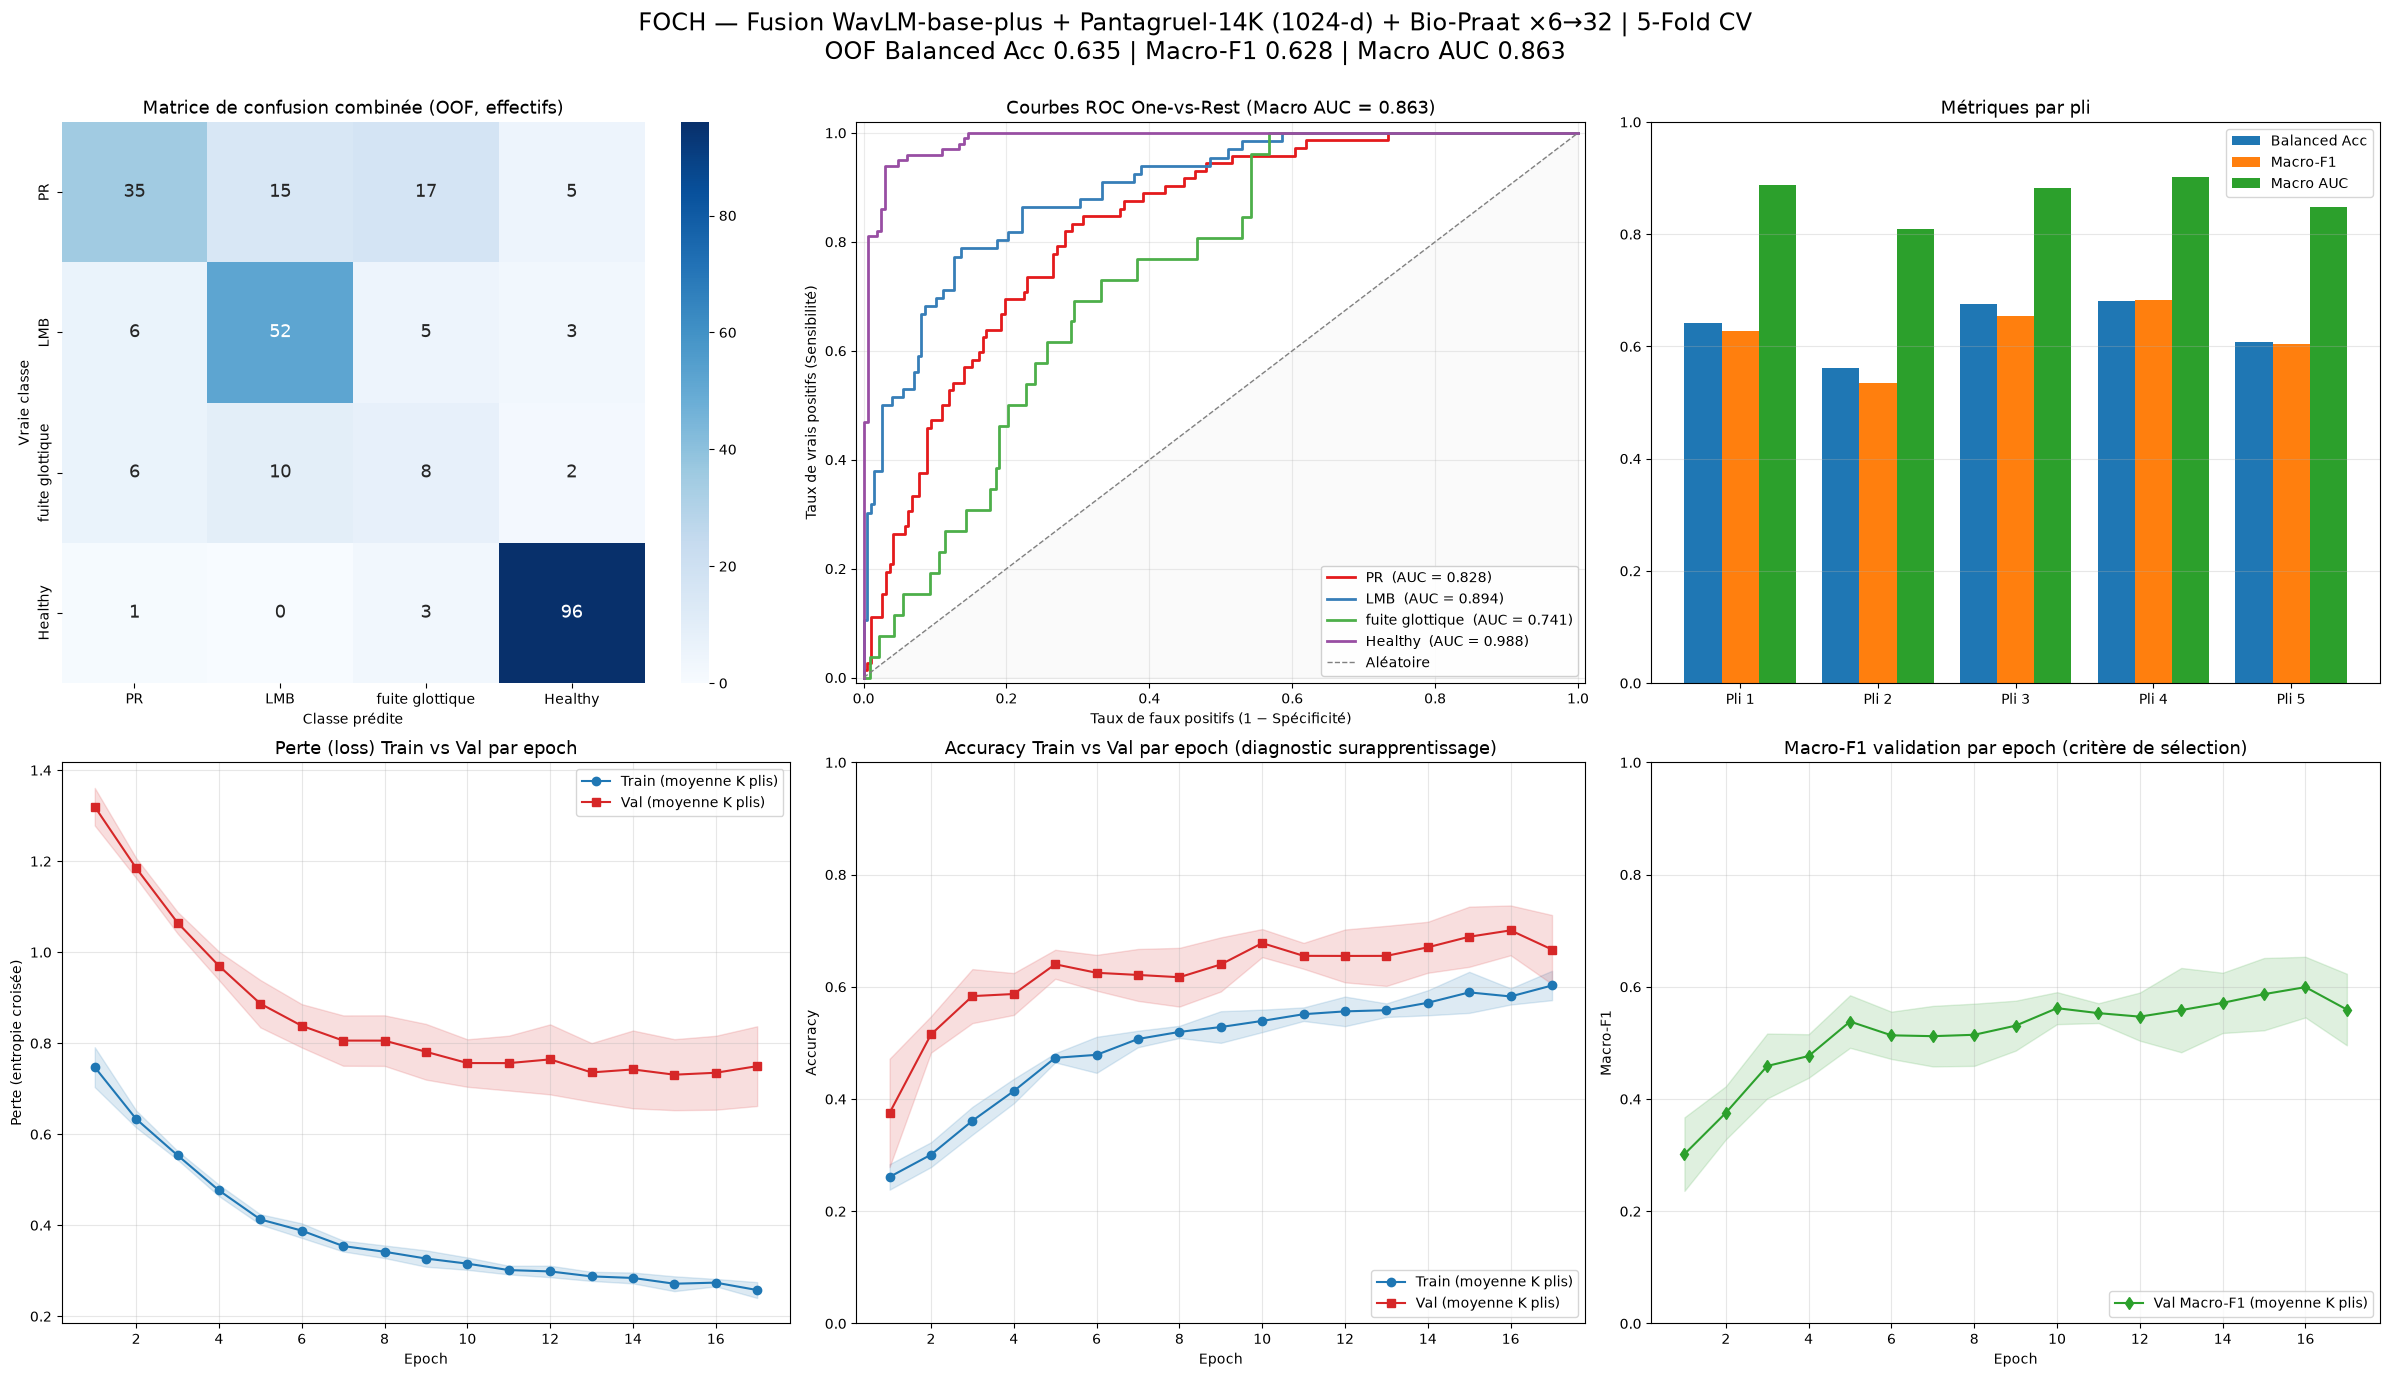


Artefacts sauvegardés dans C:/Users/AdminIA/Documents/models/.foch_métriques :
  • pantagruel_wavlm_bp_bio_kfold_aug_dashboard.png
  • pantagruel_wavlm_bp_bio_kfold_aug_metrics.json
  • pantagruel_wavlm_bp_bio_kfold_aug_confusion.csv
  • pantagruel_wavlm_bp_bio_kfold_aug_fold_metrics.csv


In [9]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 8 — Évaluation agrégée out-of-fold (K-Fold) + tableau de bord
# ═══════════════════════════════════════════════════════════════════════════
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, auc as sk_auc)
from sklearn.preprocessing import label_binarize

assert (oof_labels >= 0).all(), "Des enregistrements n'ont pas été évalués !"

# ── Métriques agrégées ────────────────────────────────────────────────────────
print('Rapport de classification agrégé (out-of-fold) :')
print('\n' + classification_report(oof_labels, oof_preds, labels=labels_idx,
                                    target_names=CLASSES, digits=3, zero_division=0))
oof_bal = balanced_accuracy_score(oof_labels, oof_preds)
oof_mf1 = f1_score(oof_labels, oof_preds, average='macro', zero_division=0)
try:
    oof_auc = roc_auc_score(oof_labels, oof_probs, multi_class='ovr',
                            average='macro', labels=labels_idx)
except ValueError:
    oof_auc = float('nan')

mean_bal, std_bal = fold_df['balanced_accuracy'].mean(), fold_df['balanced_accuracy'].std()
mean_f1,  std_f1  = fold_df['macro_f1'].mean(),          fold_df['macro_f1'].std()
mean_auc, std_auc = fold_df['macro_auc_ovr'].mean(),     fold_df['macro_auc_ovr'].std()
print(f'OOF global        — Balanced Acc {oof_bal:.4f} | Macro-F1 {oof_mf1:.4f} | Macro AUC {oof_auc:.4f}')
print(f'Moyenne par pli   — Balanced Acc {mean_bal:.4f}±{std_bal:.4f} | '
      f'Macro-F1 {mean_f1:.4f}±{std_f1:.4f} | Macro AUC {mean_auc:.4f}±{std_auc:.4f}')

# ── Titre dynamique : reflète le preset réellement actif ──────────────────────
_arch_names = []
if WAVLM_VARIANT:   _arch_names.append(f'WavLM-{WAVLM_VARIANT.replace("_", "-")}')
if USE_PANTAGRUEL:  _arch_names.append(f'Pantagruel-14K ({PANTAGRUEL_EMB_DIM}-d)')
if USE_BIO:         _arch_names.append(f'Bio-Praat ×{N_BIO_FEATURES}→{BIO_PROJ_DIM}')
_arch_txt = ' + '.join(_arch_names) if _arch_names else BACKBONE

# ── ROC par classe (One-vs-Rest) ──────────────────────────────────────────────
oof_labels_bin = label_binarize(oof_labels, classes=labels_idx)   # (n, 4)

# ── Tableau de bord 2×3 ───────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(24, 14))
fig.suptitle(f'FOCH — Fusion {_arch_txt} | {K_FOLDS}-Fold CV\n'
             f'OOF Balanced Acc {oof_bal:.3f} | Macro-F1 {oof_mf1:.3f} | Macro AUC {oof_auc:.3f}',
             fontsize=17)

# ── [0, 0] Matrice de confusion (effectifs bruts) ─────────────────────────────
cm = confusion_matrix(oof_labels, oof_preds, labels=labels_idx)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=CLASSES, yticklabels=CLASSES, annot_kws={'size': 13})
axes[0, 0].set_title('Matrice de confusion combinée (OOF, effectifs)', fontsize=13)
axes[0, 0].set_ylabel('Vraie classe')
axes[0, 0].set_xlabel('Classe prédite')

# ── [0, 1] Courbes ROC OvR par classe ────────────────────────────────────────
_colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']   # rouge, bleu, vert, violet
for i, (cls, col) in enumerate(zip(CLASSES, _colors)):
    fpr, tpr, _ = roc_curve(oof_labels_bin[:, i], oof_probs[:, i])
    auc_i = sk_auc(fpr, tpr)
    axes[0, 1].plot(fpr, tpr, color=col, lw=2, label=f'{cls}  (AUC = {auc_i:.3f})')

axes[0, 1].plot([0, 1], [0, 1], color='grey', lw=1, linestyle='--', label='Aléatoire')
axes[0, 1].fill_between([0, 1], [0, 1], alpha=0.04, color='grey')
axes[0, 1].set_xlim([-0.01, 1.01]); axes[0, 1].set_ylim([-0.01, 1.02])
axes[0, 1].set_xlabel('Taux de faux positifs (1 − Spécificité)')
axes[0, 1].set_ylabel('Taux de vrais positifs (Sensibilité)')
axes[0, 1].set_title(f'Courbes ROC One-vs-Rest (Macro AUC = {oof_auc:.3f})', fontsize=13)
axes[0, 1].legend(loc='lower right', framealpha=0.9)
axes[0, 1].grid(True, alpha=0.25)

# ── [0, 2] Métriques par pli ──────────────────────────────────────────────────
x = np.arange(K_FOLDS); w = 0.27
axes[0, 2].bar(x - w, fold_df['balanced_accuracy'], w, label='Balanced Acc')
axes[0, 2].bar(x,     fold_df['macro_f1'],          w, label='Macro-F1')
axes[0, 2].bar(x + w, fold_df['macro_auc_ovr'],     w, label='Macro AUC')
axes[0, 2].set_title('Métriques par pli', fontsize=13)
axes[0, 2].set_xticks(x)
axes[0, 2].set_xticklabels([f'Pli {i+1}' for i in range(K_FOLDS)])
axes[0, 2].set_ylim(0, 1)
axes[0, 2].legend()
axes[0, 2].grid(True, axis='y', alpha=0.3)

# ── [1, 0] Perte (loss) Train vs Val par epoch ────────────────────────────────
assert 'fold_train_loss' in globals() and len(fold_train_loss), \
    "fold_train_loss manquant — réexécutez la Cellule 7 (boucle K-Fold) pour régénérer l'historique."
min_ep_loss = min(min(len(h) for h in fold_train_loss),
                   min(len(h) for h in fold_curves))
tr_loss = np.array([h[:min_ep_loss] for h in fold_train_loss])   # (K, min_ep)
va_loss = np.array([h[:min_ep_loss] for h in fold_curves])
ep_loss = np.arange(1, min_ep_loss + 1)
axes[1, 0].plot(ep_loss, tr_loss.mean(0), 'o-', color='#1f77b4', label='Train (moyenne K plis)')
axes[1, 0].fill_between(ep_loss, tr_loss.mean(0) - tr_loss.std(0), tr_loss.mean(0) + tr_loss.std(0),
                        color='#1f77b4', alpha=0.15)
axes[1, 0].plot(ep_loss, va_loss.mean(0), 's-', color='#d62728', label='Val (moyenne K plis)')
axes[1, 0].fill_between(ep_loss, va_loss.mean(0) - va_loss.std(0), va_loss.mean(0) + va_loss.std(0),
                        color='#d62728', alpha=0.15)
axes[1, 0].set_title('Perte (loss) Train vs Val par epoch', fontsize=13)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Perte (entropie croisée)')
axes[1, 0].legend(loc='upper right')
axes[1, 0].grid(True, alpha=0.3)

# ── [1, 1] Diagnostic de surapprentissage : Train vs Val accuracy / epoch ─────
assert 'fold_train_acc' in globals() and 'fold_val_acc' in globals() \
        and len(fold_train_acc) and len(fold_val_acc), \
    "fold_train_acc/fold_val_acc manquant — réexécutez la Cellule 7 (boucle K-Fold) pour régénérer l'historique."
min_ep = min(min(len(h) for h in fold_train_acc),
             min(len(h) for h in fold_val_acc))
tr = np.array([h[:min_ep] for h in fold_train_acc])   # (K, min_ep)
va = np.array([h[:min_ep] for h in fold_val_acc])
ep = np.arange(1, min_ep + 1)
axes[1, 1].plot(ep, tr.mean(0), 'o-', color='#1f77b4', label='Train (moyenne K plis)')
axes[1, 1].fill_between(ep, tr.mean(0) - tr.std(0), tr.mean(0) + tr.std(0),
                        color='#1f77b4', alpha=0.15)
axes[1, 1].plot(ep, va.mean(0), 's-', color='#d62728', label='Val (moyenne K plis)')
axes[1, 1].fill_between(ep, va.mean(0) - va.std(0), va.mean(0) + va.std(0),
                        color='#d62728', alpha=0.15)
axes[1, 1].set_title('Accuracy Train vs Val par epoch (diagnostic surapprentissage)', fontsize=13)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].set_ylim(0, 1)
axes[1, 1].legend(loc='lower right')
axes[1, 1].grid(True, alpha=0.3)

# ── [1, 2] Macro-F1 de validation par epoch (critère de sélection) ────────────
# C'est la métrique qui pilote checkpoint et arrêt anticipé (Cellule 7) : la
# tracer explicite ce que l'entraînement a réellement optimisé.
min_ep_f1 = min(len(h) for h in fold_val_f1)
vf1 = np.array([h[:min_ep_f1] for h in fold_val_f1])
ep_f1 = np.arange(1, min_ep_f1 + 1)
axes[1, 2].plot(ep_f1, vf1.mean(0), 'd-', color='#2ca02c', label='Val Macro-F1 (moyenne K plis)')
axes[1, 2].fill_between(ep_f1, vf1.mean(0) - vf1.std(0), vf1.mean(0) + vf1.std(0),
                        color='#2ca02c', alpha=0.15)
axes[1, 2].set_title('Macro-F1 validation par epoch (critère de sélection)', fontsize=13)
axes[1, 2].set_xlabel('Epoch')
axes[1, 2].set_ylabel('Macro-F1')
axes[1, 2].set_ylim(0, 1)
axes[1, 2].legend(loc='lower right')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.subplots_adjust(top=0.90)
fig_path = os.path.join(METRICS_DIR, f'{RUN_NAME}_dashboard.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()

# ── Sauvegarde des artefacts ──────────────────────────────────────────────────
report_dict = classification_report(oof_labels, oof_preds, labels=labels_idx,
                                     target_names=CLASSES, output_dict=True, zero_division=0)
metrics = {
    'run_name':               RUN_NAME,
    'architecture':           _arch_txt,
    'preset':                 BACKBONE,
    'branches':               {'wavlm': WAVLM_VARIANT, 'pantagruel': USE_PANTAGRUEL, 'bio': USE_BIO},
    'fusion_dim':             int(FUSION_DIM_EXPECTED),
    'pantagruel_emb_dim':     int(PANTAGRUEL_EMB_DIM),
    'encoders_frozen':        True,
    'bio_features':           list(BIO_FEATURES) if USE_BIO else [],
    'bio_proj_dim':           BIO_PROJ_DIM if USE_BIO else 0,
    # Statistiques bio PAR PLI : leur variation d'un pli à l'autre atteste
    # qu'elles sont calculées sur le seul train, et non globalement.
    'bio_stats_per_fold':     fold_bio_stats,
    'cv':                     f'StratifiedKFold(n_splits={K_FOLDS})',
    'oof_balanced_accuracy':  oof_bal,
    'oof_macro_f1':           oof_mf1,
    'oof_macro_auc_ovr':      oof_auc,
    'mean_balanced_accuracy': mean_bal, 'std_balanced_accuracy': std_bal,
    'mean_macro_f1':          mean_f1,  'std_macro_f1':          std_f1,
    'mean_macro_auc_ovr':     mean_auc, 'std_macro_auc_ovr':     std_auc,
    'per_fold':               fold_rows,
    'per_class_oof':          report_dict,
    'classes':                CLASSES,
    'n_total':                int(len(df)),
}
with open(os.path.join(METRICS_DIR, f'{RUN_NAME}_metrics.json'), 'w', encoding='utf-8') as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2, default=float)
np.savetxt(os.path.join(METRICS_DIR, f'{RUN_NAME}_confusion.csv'), cm, fmt='%d', delimiter=',')
fold_df.to_csv(os.path.join(METRICS_DIR, f'{RUN_NAME}_fold_metrics.csv'), index=False)

print(f'\nArtefacts sauvegardés dans {METRICS_DIR} :')
print(f'  • {RUN_NAME}_dashboard.png')
print(f'  • {RUN_NAME}_metrics.json')
print(f'  • {RUN_NAME}_confusion.csv')
print(f'  • {RUN_NAME}_fold_metrics.csv')

## 9. Synthèse et prochaines étapes

Ce notebook met en œuvre un **classifieur tri-branche configurable** (préréglages `BACKBONE`, Cellule 1) évalué par **validation croisée stratifiée à 5 plis**, avec **augmentation de données** injectée pli par pli dans le seul jeu d'entraînement. Les trois branches — WavLM Base-Plus, Pantagruel `speech-large-14K`, descripteurs bioacoustiques Praat — partagent la même boucle d'entraînement (Cellule 7) et le même `Dataset` (Cellule 4) ; seule la dimension de fusion s'adapte automatiquement aux branches actives (`MultiBranchFusion`, Cellule 6).

**Configuration active : `BACKBONE = 'pantagruel_wavlm_bp_bio'`** → WavLM Base-Plus (768-d, gelé) ⊕ Pantagruel-14K (dimension résolue à l'exécution, gelé) ⊕ projection bioacoustique (`BIO_PROJ_DIM`-d, entraînable).

> ℹ️ **Aucun résultat chiffré n'est reporté ici.** Les métriques de ce notebook sont produites par l'exécution (Cellules 7 et 8) et écrites dans `.foch_métriques`. Les chiffres des notebooks antérieurs décrivent d'autres architectures et ne constituent pas une référence valide pour celle-ci ; la seule comparaison légitime est celle des presets de **ce** notebook entre eux, tous évalués sur les mêmes plis et la même graine.

**Choix méthodologiques clés :**
- **Appariement linguistique** : Pantagruel est pré-entraîné sur ~14 000 h de parole française, là où WavLM (anglais) et les backbones AudioSet des notebooks précédents subissaient un décalage de domaine face à un corpus francophone. Ce gain ne coûte aucun paramètre entraînable puisque l'encodeur reste gelé.
- **Complémentarité plutôt qu'arbitrage** : WavLM Base-Plus (objectif de débruitage/mélange de locuteurs → détail microscopique) et Pantagruel (représentation phonétique/prosodique française) sont concaténés ; les presets solo mesurent l'apport réel de chacun.
- **Résolution de dimension à l'exécution** : la dimension de Pantagruel est lue depuis `config.embed_dim` (et non `hidden_size`, valeur héritée inutilisée), puis **revérifiée sur une passe avant réelle** avec assertion bloquante — aucune dimension n'est écrite en dur.
- **Fine-tuning limité à la tête** : les deux encodeurs sont intégralement gelés, ~300 échantillons d'entraînement ne pouvant remodeler 407 M paramètres. Le notebook ne contient **aucune** logique de dégel progressif : elle a été retirée du code, pas désactivée.
- **Branche bioacoustique ciblée** : CPPS, jitter, shimmer, HNR et statistiques de F0 visent spécifiquement la confusion `fuite glottique` ↔ `PR`, toutes deux des atteintes de la qualité de fermeture glottique qu'un encodeur auto-supervisé n'a aucune obligation d'encoder explicitement. Descripteurs isolés par `try/except`, sentinelle `NaN` par mesure en échec, imputation et normalisation **au niveau du pli**.
- **Validation croisée sans fuite** : déduplication patient en amont, augmentation injectée dans le seul train après exclusion des patients de validation (assertion), poids de classes **et** statistiques bioacoustiques recalculés sur le seul `train_full` de chaque pli.

**Pistes d'amélioration ultérieures :**
1. **Exécuter la grille d'ablation** (`pantagruel_solo`, `wavlm_bp_solo`, `bio_solo`, `pantagruel_wavlm_bp`, puis le preset complet) — même graine, mêmes plis — pour attribuer le gain à chaque branche plutôt qu'au tout.
2. **Examiner le bloc `PR` ↔ `fuite glottique`** de la matrice de confusion avec et sans branche bioacoustique : c'est le test direct de l'hypothèse qui motive cette branche.
3. **Étendre `BIO_FEATURES`** — CPP non lissé, quotients de perturbation (RAP, PPQ5, APQ11), rapport harmonique glottal (GNE), pente spectrale H1−H2. Il suffit d'enregistrer une fonction dans `_BIO_EXTRACTORS` et de citer son nom : `N_BIO_FEATURES` et la projection suivent.
4. **Pondération par couche de Pantagruel** — au lieu de la dernière couche seule, apprendre une combinaison convexe des 16 couches (à la ELMo/SUPERB) : les couches intermédiaires portent souvent davantage d'information paralinguistique que la dernière, sans dégeler quoi que ce soit.
5. **Mise en cache disque des embeddings gelés** — les deux encodeurs étant figés, leurs sorties sont constantes d'une époque à l'autre : les précalculer une fois supprimerait l'essentiel du coût de chaque exécution et rendrait la grille d'ablation quasi gratuite.
6. **Ensembling** des K modèles de plis à l'inférence.
7. **Audit qualité** des doublons d'homonymes (`Last_Name` est un proxy patient imparfait) via `patient_id`.

> ⚠️ **Rappel d'exécution** — cellules à exécuter **dans l'ordre** (1 → 8). Tous les modèles sont chargés **localement** (`HF_HUB_OFFLINE=1`, `local_files_only=True`) : aucune connexion à `huggingface.co` n'est tentée. Pantagruel requiert `trust_remote_code=True` **et** le paquet `timm` dans l'environnement `.aug` (importé par `modeling_pantagruel_uni.py`). La Cellule 7 entraîne **K = 5 modèles** : prévoir un GPU CUDA et un temps d'exécution conséquent — le premier pli paie en plus le calcul des descripteurs Praat, mis en cache ensuite.